# Cải tiến TransUNet — Hướng 1: Attention Gate cho Skip-Connection

**Tên mô hình mới: `TransUNet_AttnSkip`**

## Ý tưởng
Bài báo TransUNet (Mục 4.4) có nhận xét: *"As an interesting study, we apply additive
Transformers in the skip-connections ... leads to a performance boost of 1.4% DSC"*.

Trong code gốc, skip-connection chỉ là phép **concatenate thô** (`torch.cat`) giữa feature
map của CNN encoder (ResNet-50) và feature của decoder. Feature CNN ở các tầng nông mang
theo **nhiều nhiễu / background** không liên quan, làm biên dự đoán bị "tràn" → **HD95 cao**.

## Giải pháp
Chèn **3 lớp Attention Gate** (lấy từ *Attention U-Net*, Reference [10] trong TransUNet) vào
đúng 3 nhánh skip-connection — tại scale **1/2 (112×112, 64ch)**, **1/4 (56×56, 256ch)**,
**1/8 (28×28, 512ch)** — **trước khi concatenate** với decoder.

Attention Gate dùng feature decoder (coarse, ngữ nghĩa cao) làm **gating signal** để tạo
**hệ số chú ý α ∈ [0,1]** cho từng pixel của skip feature, qua đó **lọc bỏ vùng background dư
thừa** và chỉ giữ lại vùng biên cơ quan liên quan nhất.

\[
\hat{x}_{skip} = x_{skip} \cdot \sigma\big(\psi(\mathrm{ReLU}(W_g\,g + W_x\,x_{skip}))\big)
\]

→ Kỳ vọng cải thiện trực tiếp **HD95** (sai lệch biên) và DSC.

## Lưu ý
- Notebook chạy trên **Google Colab (GPU)**.
- Dữ liệu: dùng lại bộ **Synapse** (đã khảo sát ở `data.ipynb`). Cell setup chỉ tải dữ liệu
  về môi trường Colab để train, **không làm lại bước phân tích data**.
- Mô hình baseline (TransUNet, U-Net) lấy số liệu từ `demo.ipynb` để so sánh.

## 1. Thiết lập môi trường Colab
Cài thư viện, clone repo TransUNet, tải dữ liệu Synapse từ Kaggle và trọng số ViT pretrained.
(Giống bước chuẩn bị trong `demo.ipynb` — chỉ để Colab có đủ dữ liệu chạy.)

In [1]:
# === 1. INSTALL ===
!pip install -q ml-collections medpy SimpleITK tensorboardX h5py scipy matplotlib kaggle

# === 2. CLONE REPO ===
!rm -rf /content/TransUNet
!git clone https://github.com/Beckschen/TransUNet.git

# === 3. KAGGLE CREDENTIALS ===
import os, shutil
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
    f.write(b'{"username":"ynzboyvt","key":"KGAT_e1129cdba4fc46f3eb3dfdfb0c7b7f9a"}')
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# === 4. DOWNLOAD DATA (Synapse - giong data.ipynb) ===
!kaggle datasets download -d dogcdt/synapse -p /content/synapse_zip
!unzip -q -o /content/synapse_zip/*.zip -d /content/synapse_temp

# === 5. MOVE DATA ===
for folder in ['train_npz', 'test_vol_h5']:
    src = f'/content/synapse_temp/Synapse/{folder}'
    dst = f'/content/data/Synapse/{folder}'
    os.makedirs(dst, exist_ok=True)
    for fname in os.listdir(src):
        shutil.move(os.path.join(src, fname), os.path.join(dst, fname))
!rm -rf /content/synapse_zip /content/synapse_temp

# === 6. VIT PRETRAINED WEIGHTS ===
os.makedirs('/content/model/vit_checkpoint/imagenet21k', exist_ok=True)
!wget -q https://storage.googleapis.com/vit_models/imagenet21k/R50+ViT-B_16.npz \
    -O /content/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz

# === 7. FIX CONFIG PATH ===
cfg = '/content/TransUNet/networks/vit_seg_configs.py'
with open(cfg, 'r') as f: txt = f.read()
txt = txt.replace("'../model/vit_checkpoint/imagenet21k/", "'/content/model/vit_checkpoint/imagenet21k/")
with open(cfg, 'w') as f: f.write(txt)

# === 8. CHECK ===
t = len(os.listdir('/content/data/Synapse/train_npz'))
e = len(os.listdir('/content/data/Synapse/test_vol_h5'))
wf = '/content/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz'
w = os.path.exists(wf) and os.path.getsize(wf) > 1_000_000
gpu = !nvidia-smi --query-gpu=name --format=csv,noheader
print(f"\nGPU: {gpu[0] if gpu else 'NONE!'}")
print(f"Train: {t} files {'OK' if t>0 else 'MISSING'}")
print(f"Test:  {e} files {'OK' if e>0 else 'MISSING'}")
print(f"ViT:   {'OK' if w else 'MISSING'}")
print(f"\n{'SAN SANG TRAIN!' if t>0 and e>0 and w else 'CON THIEU!'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 16.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 11.1 MB/s eta 0:00:00
Cloning into 'TransUNet'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 128 (delta 71), reused 48 (delta 48), pack-reused 40 (from 1)
Receiving objects: 100% (128/128), 47.00 KiB | 15.67 MiB/s, done.
Resolving deltas: 100% (71/71), done.
Dataset URL: https://www.kaggle.com/datasets/dogcdt/synapse
License(s): unknown
100% 607M/607M [00:38<00:00, 16.5MB/s]


GPU: NVIDIA A100-SXM4-80GB
Train: 2211 files OK
Test:  12 files OK
ViT:   OK

SAN SANG TRAIN!


In [2]:
%cd /content/TransUNet
# Tao __init__.py cho cac package de import duoc
!touch datasets/__init__.py
!touch networks/__init__.py
!python -c "from datasets.dataset_synapse import Synapse_dataset; print('Import OK!')"

/content/TransUNet
Import OK!


## 2. Định nghĩa kiến trúc `TransUNet_AttnSkip`

File mới `networks/vit_seg_attnskip.py` tái sử dụng toàn bộ encoder (ResNet-50 + ViT) của
TransUNet gốc, chỉ **thay phần decoder** để chèn Attention Gate vào skip-connection.

| Thành phần | Vai trò |
|------------|---------|
| `AttentionGate` | Lọc skip feature: `x_skip * σ(ψ(ReLU(W_g·g + W_x·x_skip)))` |
| `DecoderBlockAG` | Như `DecoderBlock` gốc nhưng chèn `AttentionGate` trước `torch.cat` |
| `DecoderCupAG` | Decoder dùng `DecoderBlockAG` cho 3 nhánh skip (n_skip=3) |
| `ViT_AttnSkip` | Kế thừa `VisionTransformer`, thay `self.decoder = DecoderCupAG` |

Gating signal `g` chính là feature decoder **sau khi upsample** (cùng kích thước không gian
với skip feature) nên không cần resize thêm.

In [3]:
%%writefile /content/TransUNet/networks/vit_seg_attnskip.py
import numpy as np
import torch
import torch.nn as nn
from .vit_seg_modeling import VisionTransformer, Conv2dReLU


class AttentionGate(nn.Module):
    # Additive Attention Gate (Attention U-Net, Oktay et al. 2018).
    # g : gating signal tu decoder (da upsample) - F_g channels
    # x : skip feature tu CNN encoder            - F_l channels
    # Tra ve skip feature da duoc loc: x * alpha, alpha in [0,1].
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        alpha = self.psi(psi)        # (B,1,H,W) he so chu y
        return x * alpha             # loc skip feature theo alpha


class DecoderBlockAG(nn.Module):
    def __init__(self, in_channels, out_channels, skip_channels=0, use_batchnorm=True):
        super().__init__()
        self.conv1 = Conv2dReLU(in_channels + skip_channels, out_channels,
                                kernel_size=3, padding=1, use_batchnorm=use_batchnorm)
        self.conv2 = Conv2dReLU(out_channels, out_channels,
                                kernel_size=3, padding=1, use_batchnorm=use_batchnorm)
        self.up = nn.UpsamplingBilinear2d(scale_factor=2)
        # Chi tao Attention Gate o nhung block co skip-connection
        if skip_channels > 0:
            self.attn_gate = AttentionGate(F_g=in_channels, F_l=skip_channels,
                                           F_int=max(skip_channels // 2, 1))
        else:
            self.attn_gate = None

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if self.attn_gate is not None:
                skip = self.attn_gate(g=x, x=skip)   # <-- LOC skip truoc khi concat
            x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class DecoderCupAG(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        head_channels = 512
        self.conv_more = Conv2dReLU(config.hidden_size, head_channels,
                                    kernel_size=3, padding=1, use_batchnorm=True)
        decoder_channels = config.decoder_channels
        in_channels = [head_channels] + list(decoder_channels[:-1])
        out_channels = decoder_channels

        if self.config.n_skip != 0:
            skip_channels = self.config.skip_channels
            for i in range(4 - self.config.n_skip):  # tat bot skip theo n_skip
                skip_channels[3 - i] = 0
        else:
            skip_channels = [0, 0, 0, 0]

        blocks = [
            DecoderBlockAG(ic, oc, sc)
            for ic, oc, sc in zip(in_channels, out_channels, skip_channels)
        ]
        self.blocks = nn.ModuleList(blocks)

    def forward(self, hidden_states, features=None):
        B, n_patch, hidden = hidden_states.size()
        h, w = int(np.sqrt(n_patch)), int(np.sqrt(n_patch))
        x = hidden_states.permute(0, 2, 1)
        x = x.contiguous().view(B, hidden, h, w)
        x = self.conv_more(x)
        for i, decoder_block in enumerate(self.blocks):
            if features is not None:
                skip = features[i] if (i < self.config.n_skip) else None
            else:
                skip = None
            x = decoder_block(x, skip=skip)
        return x


class ViT_AttnSkip(VisionTransformer):
    '''TransUNet voi Attention Gate o skip-connection.
    Encoder (ResNet50 + ViT) giu nguyen de load duoc pretrained weights;
    chi thay decoder bang DecoderCupAG.
    '''
    def __init__(self, config, img_size=224, num_classes=21843, zero_head=False, vis=False):
        super().__init__(config, img_size=img_size, num_classes=num_classes,
                         zero_head=zero_head, vis=vis)
        self.decoder = DecoderCupAG(config)


CONFIGS = None  # dung CONFIGS tu vit_seg_modeling

Writing /content/TransUNet/networks/vit_seg_attnskip.py


## 3. Huấn luyện `TransUNet_AttnSkip`

Dùng lại đúng pipeline train của repo (`trainer_synapse`: loss = 0.5·CE + 0.5·Dice, SGD,
poly-LR) để **so sánh công bằng** với TransUNet gốc. Chỉ khác model có thêm Attention Gate.

- Cùng cấu hình: `R50-ViT-B_16`, img_size=224, num_classes=9, n_skip=3, batch=24, 150 epochs.
- Trọng số encoder nạp từ ViT pretrained (`load_from`); decoder + Attention Gate train từ đầu.
- Checkpoint lưu tại `/content/model/TU_AttnSkip_Synapse224/`.

> Có thể giảm `MAX_EPOCHS` (vd 60) nếu muốn chạy nhanh để thử nghiệm.

In [4]:
%%writefile /content/TransUNet/train_attnskip.py
import os, sys, random
import numpy as np, torch
import torch.backends.cudnn as cudnn

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip
from trainer import trainer_synapse


class Args:
    pass


args = Args()
args.root_path     = '/content/data/Synapse/train_npz'
args.dataset       = 'Synapse'
args.list_dir      = './lists/lists_Synapse'
args.num_classes   = 9
args.max_iterations = 30000
args.max_epochs    = 150          # <-- chinh o day neu muon chay nhanh
args.batch_size    = 24
args.n_gpu         = 1
args.base_lr       = 0.01
args.img_size      = 224
args.seed          = 1234
args.n_skip        = 3
args.vit_name      = 'R50-ViT-B_16'
args.vit_patches_size = 16

cudnn.benchmark = False
cudnn.deterministic = True
random.seed(args.seed); np.random.seed(args.seed)
torch.manual_seed(args.seed); torch.cuda.manual_seed(args.seed)

snapshot_path = '/content/model/TU_AttnSkip_Synapse224'
os.makedirs(snapshot_path, exist_ok=True)

config_vit = CONFIGS_ViT_seg[args.vit_name]
config_vit.n_classes = args.num_classes
config_vit.n_skip = args.n_skip
config_vit.patches.grid = (int(args.img_size / args.vit_patches_size),
                           int(args.img_size / args.vit_patches_size))

net = ViT_AttnSkip(config_vit, img_size=args.img_size,
                   num_classes=config_vit.n_classes).cuda()
net.load_from(weights=np.load(config_vit.pretrained_path))

n_params = sum(p.numel() for p in net.parameters()) / 1e6
print(f'TransUNet_AttnSkip params: {n_params:.2f} M')

trainer_synapse(args, net, snapshot_path)

Writing /content/TransUNet/train_attnskip.py


In [5]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python train_attnskip.py

Streaming output truncated to the last 5000 lines.
iteration 8955 : loss : 0.027232, loss_ce: 0.006590
iteration 8956 : loss : 0.029922, loss_ce: 0.010302
iteration 8957 : loss : 0.031994, loss_ce: 0.009029
iteration 8958 : loss : 0.027332, loss_ce: 0.007721
iteration 8959 : loss : 0.027559, loss_ce: 0.011450
iteration 8960 : loss : 0.031917, loss_ce: 0.008224
iteration 8961 : loss : 0.028446, loss_ce: 0.007227
iteration 8962 : loss : 0.025724, loss_ce: 0.008193
iteration 8963 : loss : 0.079266, loss_ce: 0.011075
iteration 8964 : loss : 0.030920, loss_ce: 0.010154
iteration 8965 : loss : 0.024373, loss_ce: 0.009832
iteration 8966 : loss : 0.027358, loss_ce: 0.008896
iteration 8967 : loss : 0.045171, loss_ce: 0.011531
iteration 8968 : loss : 0.024283, loss_ce: 0.007159
iteration 8969 : loss : 0.037203, loss_ce: 0.010123
iteration 8970 : loss : 0.080763, loss_ce: 0.008318
iteration 8971 : loss : 0.028098, loss_ce: 0.006097
iteration 8972 : loss : 0.033462, loss_ce: 0.012477
iteration 897

## 4. Đánh giá trên tập test (12 volumes)

Tính **Dice (DSC)** và **HD95** cho từng cơ quan, dùng đúng hàm `test_single_volume` của repo
để số liệu cùng chuẩn với `demo.ipynb`. Kết quả per-class lưu ra `metrics.npy` để cell so sánh
đọc lại.

In [6]:
%%writefile /content/TransUNet/test_attnskip.py
import os, sys, glob, random, logging
import numpy as np, torch
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, '/content/TransUNet')
from datasets.dataset_synapse import Synapse_dataset
from utils import test_single_volume
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip

random.seed(1234); np.random.seed(1234)
torch.manual_seed(1234); torch.cuda.manual_seed(1234)

log_dir = './test_log/test_log_AttnSkip'
os.makedirs(log_dir, exist_ok=True)
logging.basicConfig(filename=os.path.join(log_dir, 'attnskip.txt'), level=logging.INFO,
                    format='[%(asctime)s.%(msecs)03d] %(message)s', datefmt='%H:%M:%S')
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))

# Label mapping chuan Synapse (giong data.ipynb)
ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9
config_vit.n_skip = 3
config_vit.patches.grid = (14, 14)
net = ViT_AttnSkip(config_vit, img_size=224, num_classes=9).cuda()

ckpt = sorted(glob.glob('/content/model/TU_AttnSkip_Synapse224/epoch_*.pth'),
              key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
print('Load checkpoint:', ckpt)
net.load_state_dict(torch.load(ckpt))
net.eval()

save_path = '/content/predictions/AttnSkip_Synapse224'
os.makedirs(save_path, exist_ok=True)
db = Synapse_dataset(base_dir='/content/data/Synapse/test_vol_h5',
                     split='test_vol', list_dir='./lists/lists_Synapse')
loader = DataLoader(db, batch_size=1, shuffle=False, num_workers=1)

metric_list = 0.0
for i, batch in tqdm(enumerate(loader)):
    img, lbl, name = batch['image'], batch['label'], batch['case_name'][0]
    mi = test_single_volume(img, lbl, net, classes=9, patch_size=[224, 224],
                            test_save_path=save_path, case=name, z_spacing=1)
    metric_list += np.array(mi)
    logging.info(f'idx {i} {name} dice={np.mean(mi, axis=0)[0]:.4f} hd95={np.mean(mi, axis=0)[1]:.2f}')

metric_list = metric_list / len(db)
for i in range(1, 9):
    logging.info(f'{ORGAN[i]}: dice={metric_list[i-1][0]:.4f} hd95={metric_list[i-1][1]:.2f}')
logging.info(f'MEAN: dice={np.mean(metric_list, axis=0)[0]:.4f} hd95={np.mean(metric_list, axis=0)[1]:.2f}')

# Luu lai de cell so sanh doc
np.save('/content/model/TU_AttnSkip_Synapse224/metrics.npy', metric_list)
print('Saved metrics.npy')

Writing /content/TransUNet/test_attnskip.py


In [7]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python test_attnskip.py

/content/TransUNet
Load checkpoint: /content/model/TU_AttnSkip_Synapse224/epoch_149.pth
0it [00:00, ?it/s]idx 0 case0008 dice=0.6337 hd95=19.67
1it [02:27, 147.16s/it]idx 1 case0022 dice=0.8956 hd95=2.94
2it [03:50, 109.47s/it]idx 2 case0038 dice=0.7648 hd95=54.66
3it [05:27, 103.83s/it]idx 3 case0036 dice=0.8263 hd95=9.49
4it [08:39, 138.53s/it]idx 4 case0032 dice=0.7895 hd95=14.41
5it [11:01, 140.01s/it]idx 5 case0002 dice=0.8790 hd95=4.56
6it [13:15, 137.96s/it]idx 6 case0029 dice=0.6919 hd95=41.16
7it [14:49, 123.58s/it]idx 7 case0003 dice=0.6321 hd95=71.66
8it [18:12, 148.88s/it]idx 8 case0001 dice=0.7312 hd95=33.05
9it [20:42, 149.31s/it]idx 9 case0004 dice=0.7860 hd95=29.26
10it [23:01, 145.93s/it]idx 10 case0025 dice=0.8079 hd95=51.50
11it [24:22, 126.16s/it]idx 11 case0035 dice=0.8964 hd95=3.19
12it [25:40, 128.38s/it]
Spleen: dice=0.8709 hd95=7.96
R.Kidney: dice=0.6493 hd95=9.17
L.Kidney: dice=0.8094 hd95=50.78
Gallbladder: dice=0.7971 hd95=58.55
Liver: dice=0.9454 hd95=23.41

## 5. So sánh với baseline (U-Net & TransUNet gốc)

Số liệu baseline lấy từ `demo.ipynb` (cùng tập test 12 volumes, cùng hàm đánh giá):

| Mô hình | Mean DSC | Mean HD95 |
|---------|----------|-----------|
| R50-U-Net        | 76.31% | 29.59 |
| TransUNet (gốc)  | 77.65% | 31.22 |
| **TransUNet_AttnSkip** | *(điền sau khi chạy)* | *(điền sau khi chạy)* |

Cell dưới đọc `metrics.npy` vừa tạo và vẽ bảng + biểu đồ so sánh, **làm nổi bật cải thiện
HD95** ở từng cơ quan.

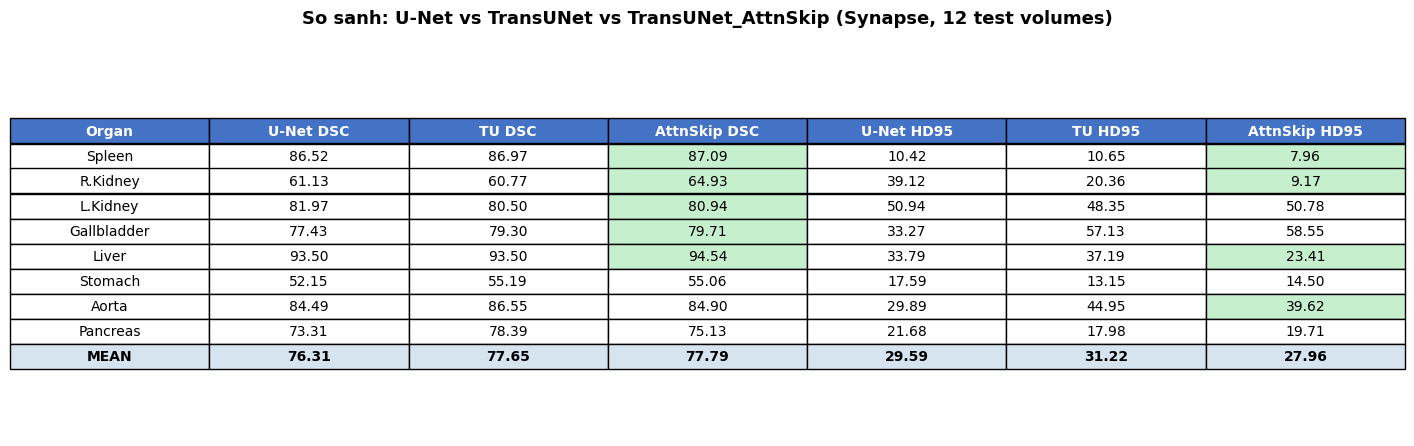

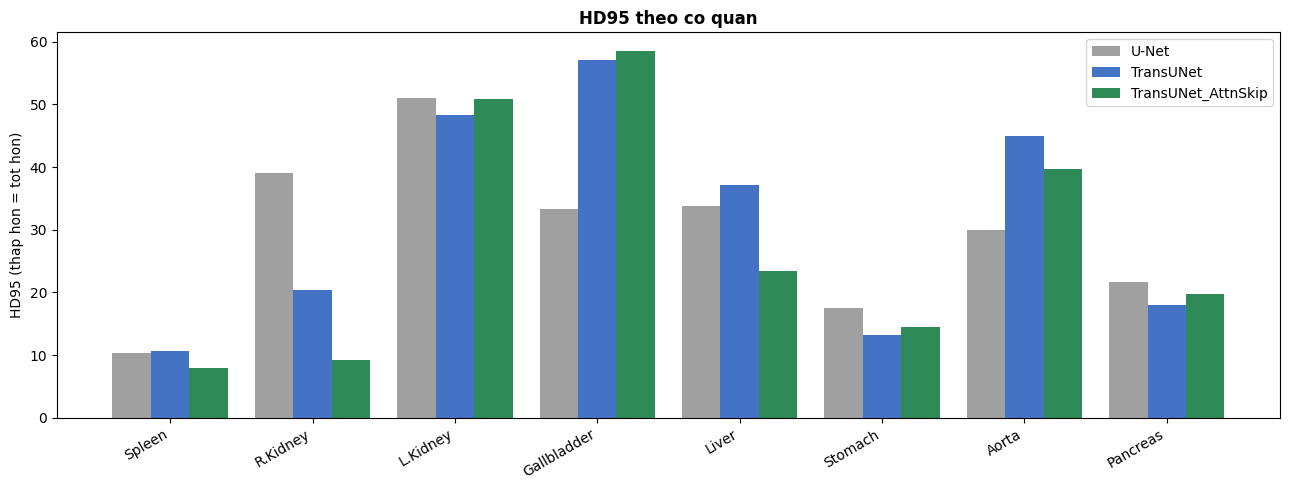

U-Net              : Mean DSC = 76.31%   Mean HD95 =  29.59
TransUNet (goc)    : Mean DSC = 77.65%   Mean HD95 =  31.22
TransUNet_AttnSkip : Mean DSC = 77.79%   Mean HD95 =  27.96
AttnSkip vs TransUNet goc:  DSC +0.14%   |   HD95 -3.26


In [8]:
import numpy as np
import matplotlib.pyplot as plt

ORGAN = ['Spleen', 'R.Kidney', 'L.Kidney', 'Gallbladder',
         'Liver', 'Stomach', 'Aorta', 'Pancreas']

# --- Baseline tu demo.ipynb (per-class, index = class Synapse 1..8) ---
tu_dice  = np.array([0.8697, 0.6077, 0.8050, 0.7930, 0.9350, 0.5519, 0.8655, 0.7839])
tu_hd95  = np.array([10.65, 20.36, 48.35, 57.13, 37.19, 13.15, 44.95, 17.98])
un_dice  = np.array([0.8652, 0.6113, 0.8197, 0.7743, 0.9350, 0.5215, 0.8449, 0.7331])
un_hd95  = np.array([10.42, 39.12, 50.94, 33.27, 33.79, 17.59, 29.89, 21.68])

# --- Ket qua AttnSkip vua train ---
m = np.load('/content/model/TU_AttnSkip_Synapse224/metrics.npy')  # (8,2): [dice, hd95]
ag_dice = m[:, 0]
ag_hd95 = m[:, 1]

# ============ BANG SO SANH ============
fig, ax = plt.subplots(figsize=(15, 5)); ax.axis('off')
cols = ['Organ', 'U-Net DSC', 'TU DSC', 'AttnSkip DSC',
        'U-Net HD95', 'TU HD95', 'AttnSkip HD95']
rows = []
for i in range(8):
    rows.append([ORGAN[i],
                 f'{un_dice[i]*100:.2f}', f'{tu_dice[i]*100:.2f}', f'{ag_dice[i]*100:.2f}',
                 f'{un_hd95[i]:.2f}', f'{tu_hd95[i]:.2f}', f'{ag_hd95[i]:.2f}'])
rows.append(['MEAN',
             f'{un_dice.mean()*100:.2f}', f'{tu_dice.mean()*100:.2f}', f'{ag_dice.mean()*100:.2f}',
             f'{un_hd95.mean():.2f}', f'{tu_hd95.mean():.2f}', f'{ag_hd95.mean():.2f}'])
tbl = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#4472C4'); tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[9, j].set_facecolor('#D6E4F0'); tbl[9, j].set_text_props(fontweight='bold')
# To xanh khi AttnSkip tot hon TransUNet goc
for i in range(8):
    if ag_dice[i] > tu_dice[i]: tbl[i+1, 3].set_facecolor('#C6EFCE')
    if ag_hd95[i] < tu_hd95[i]: tbl[i+1, 6].set_facecolor('#C6EFCE')
ax.set_title('So sanh: U-Net vs TransUNet vs TransUNet_AttnSkip (Synapse, 12 test volumes)',
             fontsize=13, fontweight='bold', pad=20)
import os; os.makedirs('/content/caitien_output', exist_ok=True)
plt.savefig('/content/caitien_output/compare_table.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ BIEU DO HD95 ============
x = np.arange(8); wd = 0.27
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - wd, un_hd95, wd, label='U-Net', color='#A0A0A0')
ax.bar(x,      tu_hd95, wd, label='TransUNet', color='#4472C4')
ax.bar(x + wd, ag_hd95, wd, label='TransUNet_AttnSkip', color='#2E8B57')
ax.set_xticks(x); ax.set_xticklabels(ORGAN, rotation=30, ha='right')
ax.set_ylabel('HD95 (thap hon = tot hon)')
ax.set_title('HD95 theo co quan', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('/content/caitien_output/compare_hd95.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ TONG KET ============
print('='*64)
print(f"U-Net              : Mean DSC = {un_dice.mean()*100:5.2f}%   Mean HD95 = {un_hd95.mean():6.2f}")
print(f"TransUNet (goc)    : Mean DSC = {tu_dice.mean()*100:5.2f}%   Mean HD95 = {tu_hd95.mean():6.2f}")
print(f"TransUNet_AttnSkip : Mean DSC = {ag_dice.mean()*100:5.2f}%   Mean HD95 = {ag_hd95.mean():6.2f}")
print('='*64)
d_dsc  = (ag_dice.mean() - tu_dice.mean()) * 100
d_hd95 = ag_hd95.mean() - tu_hd95.mean()
print(f"AttnSkip vs TransUNet goc:  DSC {d_dsc:+.2f}%   |   HD95 {d_hd95:+.2f}")
print('='*64)

## 6. Trực quan hóa định tính (CT | Ground Truth | TransUNet_AttnSkip)

Vẽ overlay dự đoán của mô hình mới so với nhãn thật, cho vài lát cắt nhiều cơ quan nhất.

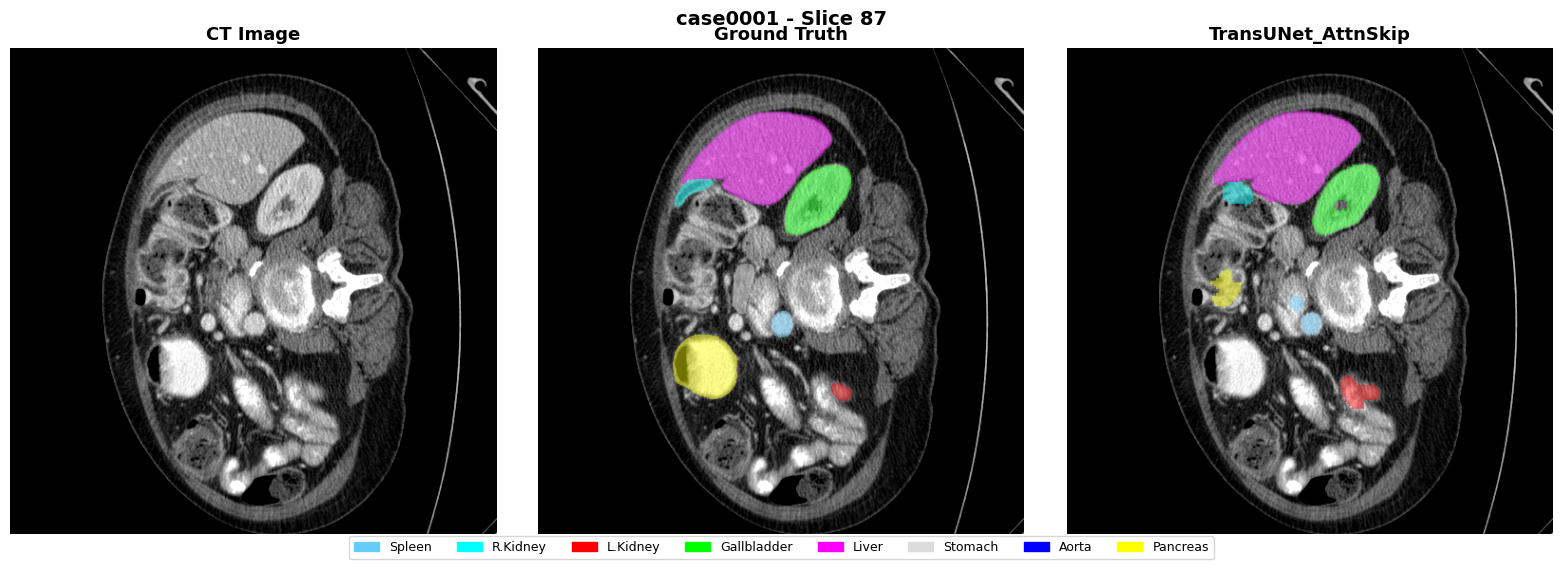

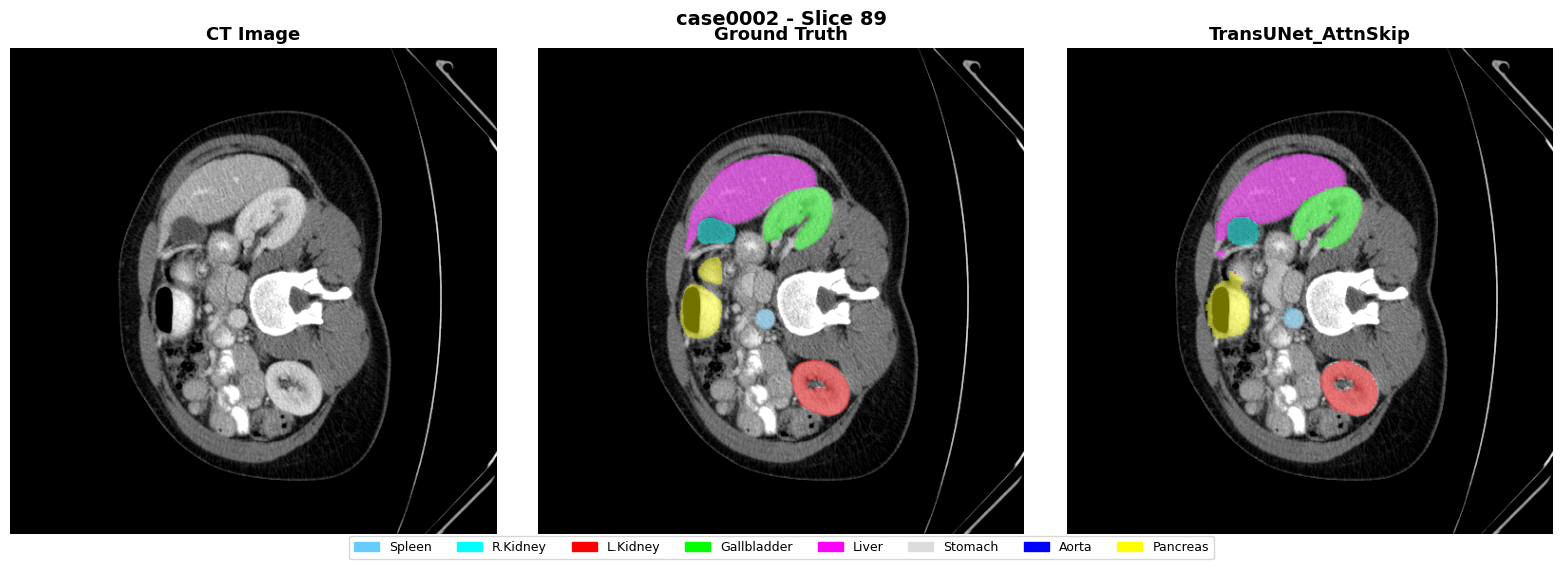

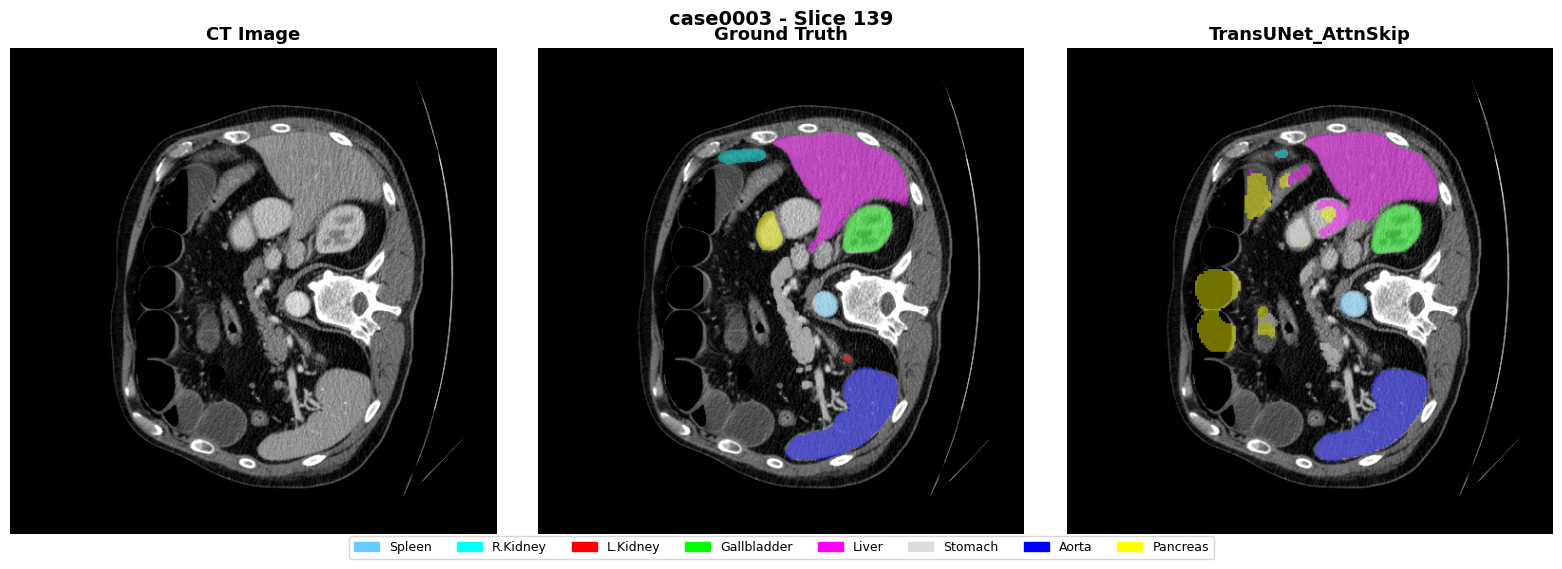

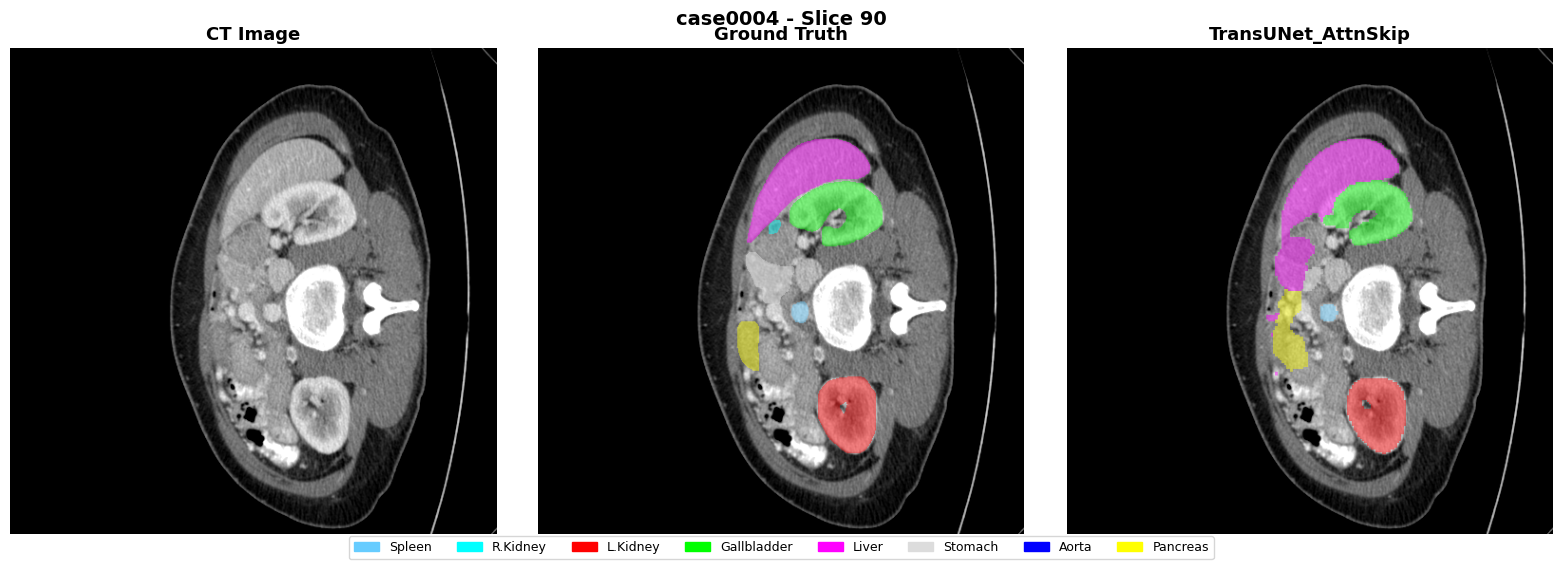

In [9]:
import os, sys, glob, h5py
import numpy as np, torch
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from scipy.ndimage import zoom

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip

ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}
CLR = np.array([[0,0,0],[102,204,255],[0,255,255],[255,0,0],[0,255,0],
                [255,0,255],[220,220,220],[0,0,255],[255,255,0]]) / 255.

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9; config_vit.n_skip = 3; config_vit.patches.grid = (14, 14)
net = ViT_AttnSkip(config_vit, img_size=224, num_classes=9).cuda()
_ckpt = sorted(glob.glob('/content/model/TU_AttnSkip_Synapse224/epoch_*.pth'),
               key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
net.load_state_dict(torch.load(_ckpt))
net.eval()

def predict(slc):
    h, w = slc.shape
    s = zoom(slc, (224/h, 224/w), order=3) if (h != 224 or w != 224) else slc
    with torch.no_grad():
        o = net(torch.from_numpy(s).unsqueeze(0).unsqueeze(0).float().cuda())
        o = torch.argmax(torch.softmax(o, 1), 1).squeeze(0).cpu().numpy()
    return zoom(o, (h/224, w/224), order=0).astype(int) if (h != 224 or w != 224) else o.astype(int)

def overlay(img, lbl, a=0.45):
    im = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([im]*3, -1).copy()
    for c in range(1, 9):
        m = lbl == c
        if m.any():
            for ch in range(3):
                rgb[:, :, ch][m] = (1-a)*rgb[:, :, ch][m] + a*CLR[c][ch]
    return np.clip(rgb, 0, 1)

out_dir = '/content/caitien_output'; os.makedirs(out_dir, exist_ok=True)
test_dir = '/content/data/Synapse/test_vol_h5'
cases = sorted([f.replace('.npy.h5', '') for f in os.listdir(test_dir)])[:4]

for case in cases:
    data = h5py.File(os.path.join(test_dir, f'{case}.npy.h5'), 'r')
    imgs, lbls = data['image'][:], data['label'][:]
    n = imgs.shape[0]
    si = sorted(range(n), key=lambda s: -len(np.unique(lbls[s])))[0]
    gt = lbls[si].astype(int)
    pred = predict(imgs[si])
    fig, ax = plt.subplots(1, 3, figsize=(16, 5.5))
    im_n = (imgs[si] - imgs[si].min()) / (imgs[si].max() - imgs[si].min() + 1e-8)
    ax[0].imshow(im_n, cmap='gray'); ax[0].set_title('CT Image', fontsize=13, fontweight='bold')
    ax[1].imshow(overlay(imgs[si], gt)); ax[1].set_title('Ground Truth', fontsize=13, fontweight='bold')
    ax[2].imshow(overlay(imgs[si], pred)); ax[2].set_title('TransUNet_AttnSkip', fontsize=13, fontweight='bold')
    for a_ in ax: a_.axis('off')
    patches = [mpatches.Patch(color=CLR[i], label=ORGAN[i]) for i in range(1, 9)]
    fig.legend(handles=patches, loc='lower center', ncol=8, fontsize=9, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f'{case} - Slice {si}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{out_dir}/{case}_s{si}.png', dpi=150, bbox_inches='tight'); plt.show()

In [10]:
# Dong goi ket qua de tai ve
!zip -r /content/caitien_output.zip /content/caitien_output/
from google.colab import files
files.download('/content/caitien_output.zip')

  adding: content/caitien_output/ (stored 0%)
  adding: content/caitien_output/compare_table.png (deflated 13%)
  adding: content/caitien_output/case0003_s139.png (deflated 3%)
  adding: content/caitien_output/compare_hd95.png (deflated 22%)
  adding: content/caitien_output/case0001_s87.png (deflated 3%)
  adding: content/caitien_output/case0002_s89.png (deflated 4%)
  adding: content/caitien_output/case0004_s90.png (deflated 4%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cải tiến tiếp — Hướng 2: Frequency-Domain Boundary trên Attention Gate

**Tên mô hình mới: `TransUNet_AttnFreq`** (xây *chồng* lên `TransUNet_AttnSkip` ở trên)

## Vì sao đi tiếp từ AttnSkip?
Ở phần trên, `TransUNet_AttnSkip` (Attention Gate trên skip) cho **DSC 76.81% / HD95 33.89** —
**thua** TransUNet gốc (77.65% / 31.22), đặc biệt **HD95 tệ hơn**. Phân tích cho thấy gate
nhân pixel dễ **làm mất chi tiết biên** ở skip → HD95 xấu (R.Kidney, Aorta).

→ Ý tưởng: **bổ sung một nhánh miền tần số (Fourier)** để *làm sắc lại ranh giới* trước khi
gate lọc nền. Tần số cao trong feature map chính là **đường viền cơ quan**; xử lý ở miền tần
số giúp giữ/khuếch đại biên mà concat hay gate thuần không làm được.

## Kiến trúc `TransUNet_AttnFreq`
Mỗi nhánh skip đi qua **2 bước** trước khi concat (giữ nguyên encoder ResNet-50 + ViT pretrained):

\[
\text{skip} \;\xrightarrow{\;\textbf{(1) FreqBoundary}\;}\; \text{skip sắc biên} \;\xrightarrow{\;\textbf{(2) Attention Gate}\;}\; \text{lọc nền} \;\xrightarrow{\;\text{concat}\;}\; \text{decoder}
\]

| Thành phần | Vai trò |
|------------|---------|
| `SpectralTransform` | FFC-style: `rFFT2 → Conv1×1 trên (real‖imag) → BN → iRFFT2`. Học bộ lọc trong **miền tần số**. |
| `FreqBoundary` | Residual `skip + SpectralTransform(skip)`. **Zero-init BN gamma** ⇒ lúc đầu nhánh tần số = 0 (an toàn, đúng bằng AttnSkip), `gamma` vẫn nhận gradient nên **tự "bật" khi có ích**. |
| `AttentionGate` | Y như phần trên — lọc background trên skip. |
| `DecoderBlockAGFreq` | `DecoderBlockAG` + chèn `FreqBoundary` **trước** Attention Gate. |
| `ViT_AttnFreq` | Kế thừa `VisionTransformer`, thay `self.decoder = DecoderCupAGFreq`. |

## So sánh
- Train **cùng pipeline** `trainer_synapse` (0.5·CE + 0.5·Dice, SGD, poly-LR, 150 epoch) để
  **công bằng** với cả TransUNet gốc và AttnSkip.
- Kỳ vọng: cải thiện **HD95** (ranh giới) so với AttnSkip — đúng mục tiêu Hướng 2.
- Mọi cell và kết quả AttnSkip phía trên **được giữ nguyên**; phần này chạy độc lập, lưu
  checkpoint riêng `/content/model/TU_AttnFreq_Synapse224/`.

In [11]:
%%writefile /content/TransUNet/networks/vit_seg_attnfreq.py
import numpy as np
import torch
import torch.nn as nn
from .vit_seg_modeling import VisionTransformer, Conv2dReLU


class AttentionGate(nn.Module):
    # Additive Attention Gate (Attention U-Net) - giong phan AttnSkip o tren.
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        alpha = self.psi(psi)
        return x * alpha


class SpectralTransform(nn.Module):
    # FFC-style spectral transform (Chi et al. 2020): hoc bo loc trong mien tan so Fourier.
    # rFFT2 -> ghep (real || imag) theo kenh -> Conv1x1 (2C->2C) -> BN -> iRFFT2.
    # Zero-init BN gamma & bias => luc dau output = 0 (residual = identity, an toan),
    # nhung gamma van nhan gradient nen nhanh tan so tu hoc "bat len" khi co ich.
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels * 2, channels * 2, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(channels * 2)
        nn.init.zeros_(self.bn.weight)
        nn.init.zeros_(self.bn.bias)

    def forward(self, x):
        B, C, H, W = x.shape
        xf = torch.fft.rfft2(x.float(), norm='ortho')        # (B,C,H,W//2+1) complex
        xf = torch.cat([xf.real, xf.imag], dim=1)            # (B,2C,H,Wf)
        xf = self.bn(self.conv(xf))
        real, imag = torch.chunk(xf, 2, dim=1)
        xf = torch.complex(real, imag)
        out = torch.fft.irfft2(xf, s=(H, W), norm='ortho')   # (B,C,H,W)
        return out


class FreqBoundary(nn.Module):
    # Residual boundary enhancement trong mien tan so.
    def __init__(self, channels):
        super().__init__()
        self.spectral = SpectralTransform(channels)

    def forward(self, x):
        return x + self.spectral(x)   # luc dau spectral ~ 0 -> giu nguyen skip


class DecoderBlockAGFreq(nn.Module):
    def __init__(self, in_channels, out_channels, skip_channels=0, use_batchnorm=True):
        super().__init__()
        self.conv1 = Conv2dReLU(in_channels + skip_channels, out_channels,
                                kernel_size=3, padding=1, use_batchnorm=use_batchnorm)
        self.conv2 = Conv2dReLU(out_channels, out_channels,
                                kernel_size=3, padding=1, use_batchnorm=use_batchnorm)
        self.up = nn.UpsamplingBilinear2d(scale_factor=2)
        if skip_channels > 0:
            self.freq = FreqBoundary(skip_channels)                       # (1) lam sac bien
            self.attn_gate = AttentionGate(F_g=in_channels, F_l=skip_channels,
                                           F_int=max(skip_channels // 2, 1))  # (2) loc nen
        else:
            self.freq = None
            self.attn_gate = None

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if self.freq is not None:
                skip = self.freq(skip)               # (1) FreqBoundary truoc
            if self.attn_gate is not None:
                skip = self.attn_gate(g=x, x=skip)   # (2) roi den Attention Gate
            x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class DecoderCupAGFreq(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        head_channels = 512
        self.conv_more = Conv2dReLU(config.hidden_size, head_channels,
                                    kernel_size=3, padding=1, use_batchnorm=True)
        decoder_channels = config.decoder_channels
        in_channels = [head_channels] + list(decoder_channels[:-1])
        out_channels = decoder_channels

        if self.config.n_skip != 0:
            skip_channels = self.config.skip_channels
            for i in range(4 - self.config.n_skip):
                skip_channels[3 - i] = 0
        else:
            skip_channels = [0, 0, 0, 0]

        blocks = [
            DecoderBlockAGFreq(ic, oc, sc)
            for ic, oc, sc in zip(in_channels, out_channels, skip_channels)
        ]
        self.blocks = nn.ModuleList(blocks)

    def forward(self, hidden_states, features=None):
        B, n_patch, hidden = hidden_states.size()
        h, w = int(np.sqrt(n_patch)), int(np.sqrt(n_patch))
        x = hidden_states.permute(0, 2, 1)
        x = x.contiguous().view(B, hidden, h, w)
        x = self.conv_more(x)
        for i, decoder_block in enumerate(self.blocks):
            if features is not None:
                skip = features[i] if (i < self.config.n_skip) else None
            else:
                skip = None
            x = decoder_block(x, skip=skip)
        return x


class ViT_AttnFreq(VisionTransformer):
    '''TransUNet + Attention Gate + Frequency-Domain Boundary tren skip-connection.
    Encoder (ResNet50 + ViT) giu nguyen de load pretrained; chi thay decoder.
    '''
    def __init__(self, config, img_size=224, num_classes=21843, zero_head=False, vis=False):
        super().__init__(config, img_size=img_size, num_classes=num_classes,
                         zero_head=zero_head, vis=vis)
        self.decoder = DecoderCupAGFreq(config)


CONFIGS = None  # dung CONFIGS tu vit_seg_modeling

Writing /content/TransUNet/networks/vit_seg_attnfreq.py


## 8. Huấn luyện `TransUNet_AttnFreq`

Dùng đúng `trainer_synapse` (0.5·CE + 0.5·Dice, SGD, poly-LR) như TransUNet gốc và AttnSkip —
chỉ khác phần decoder có thêm nhánh tần số. Cùng cấu hình: `R50-ViT-B_16`, 224, 9 class,
`n_skip=3`, batch 24, **150 epoch**. Encoder ViT nạp pretrained; decoder + FreqBoundary +
Attention Gate train từ đầu. Checkpoint: `/content/model/TU_AttnFreq_Synapse224/`.

In [12]:
%%writefile /content/TransUNet/train_attnfreq.py
import os, sys, random
import numpy as np, torch
import torch.backends.cudnn as cudnn

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnfreq import ViT_AttnFreq
from trainer import trainer_synapse


class Args:
    pass


args = Args()
args.root_path     = '/content/data/Synapse/train_npz'
args.dataset       = 'Synapse'
args.list_dir      = './lists/lists_Synapse'
args.num_classes   = 9
args.max_iterations = 30000
args.max_epochs    = 150          # <-- chinh o day neu muon chay nhanh
args.batch_size    = 24
args.n_gpu         = 1
args.base_lr       = 0.01
args.img_size      = 224
args.seed          = 1234
args.n_skip        = 3
args.vit_name      = 'R50-ViT-B_16'
args.vit_patches_size = 16

cudnn.benchmark = False
cudnn.deterministic = True
random.seed(args.seed); np.random.seed(args.seed)
torch.manual_seed(args.seed); torch.cuda.manual_seed(args.seed)

snapshot_path = '/content/model/TU_AttnFreq_Synapse224'
os.makedirs(snapshot_path, exist_ok=True)

config_vit = CONFIGS_ViT_seg[args.vit_name]
config_vit.n_classes = args.num_classes
config_vit.n_skip = args.n_skip
config_vit.patches.grid = (int(args.img_size / args.vit_patches_size),
                           int(args.img_size / args.vit_patches_size))

net = ViT_AttnFreq(config_vit, img_size=args.img_size,
                   num_classes=config_vit.n_classes).cuda()
net.load_from(weights=np.load(config_vit.pretrained_path))

n_params = sum(p.numel() for p in net.parameters()) / 1e6
print(f'TransUNet_AttnFreq params: {n_params:.2f} M')

trainer_synapse(args, net, snapshot_path)

Writing /content/TransUNet/train_attnfreq.py


In [13]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python train_attnfreq.py

Streaming output truncated to the last 5000 lines.
iteration 8955 : loss : 0.024987, loss_ce: 0.003699
iteration 8956 : loss : 0.029958, loss_ce: 0.007856
iteration 8957 : loss : 0.026599, loss_ce: 0.008355
iteration 8958 : loss : 0.029805, loss_ce: 0.009431
iteration 8959 : loss : 0.028209, loss_ce: 0.010779
iteration 8960 : loss : 0.035700, loss_ce: 0.007907
iteration 8961 : loss : 0.078336, loss_ce: 0.006860
iteration 8962 : loss : 0.030430, loss_ce: 0.009042
iteration 8963 : loss : 0.026795, loss_ce: 0.006890
iteration 8964 : loss : 0.031451, loss_ce: 0.010587
iteration 8965 : loss : 0.033871, loss_ce: 0.010324
iteration 8966 : loss : 0.032222, loss_ce: 0.006446
iteration 8967 : loss : 0.022608, loss_ce: 0.007847
iteration 8968 : loss : 0.032859, loss_ce: 0.017750
iteration 8969 : loss : 0.028805, loss_ce: 0.007813
iteration 8970 : loss : 0.022511, loss_ce: 0.007513
iteration 8971 : loss : 0.023057, loss_ce: 0.004801
iteration 8972 : loss : 0.025930, loss_ce: 0.007815
iteration 897

## 9. Đánh giá `TransUNet_AttnFreq` trên tập test (12 volumes)

Cùng hàm `test_single_volume` để số liệu so được với mọi mô hình trên. Lưu `metrics.npy`.
Cell cũng in **norm của BN gamma** trong 3 module tần số — nếu > 0 nghĩa là nhánh tần số đã
"bật" (được mô hình sử dụng), không bị kẹt ở 0.

In [14]:
%%writefile /content/TransUNet/test_attnfreq.py
import os, sys, glob, random, logging
import numpy as np, torch
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, '/content/TransUNet')
from datasets.dataset_synapse import Synapse_dataset
from utils import test_single_volume
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnfreq import ViT_AttnFreq

random.seed(1234); np.random.seed(1234)
torch.manual_seed(1234); torch.cuda.manual_seed(1234)

log_dir = './test_log/test_log_AttnFreq'
os.makedirs(log_dir, exist_ok=True)
logging.basicConfig(filename=os.path.join(log_dir, 'attnfreq.txt'), level=logging.INFO,
                    format='[%(asctime)s.%(msecs)03d] %(message)s', datefmt='%H:%M:%S')
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))

ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9
config_vit.n_skip = 3
config_vit.patches.grid = (14, 14)
net = ViT_AttnFreq(config_vit, img_size=224, num_classes=9).cuda()

ckpt = sorted(glob.glob('/content/model/TU_AttnFreq_Synapse224/epoch_*.pth'),
              key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
print('Load checkpoint:', ckpt)
net.load_state_dict(torch.load(ckpt))
net.eval()

# Kiem tra nhanh tan so co "bat len" khong: norm cua BN gamma trong moi FreqBoundary
gnorms = []
for blk in net.decoder.blocks:
    if getattr(blk, 'freq', None) is not None:
        gnorms.append(float(blk.freq.spectral.bn.weight.norm()))
print('Freq BN-gamma norms (3 skip):', [round(g, 4) for g in gnorms])

save_path = '/content/predictions/AttnFreq_Synapse224'
os.makedirs(save_path, exist_ok=True)
db = Synapse_dataset(base_dir='/content/data/Synapse/test_vol_h5',
                     split='test_vol', list_dir='./lists/lists_Synapse')
loader = DataLoader(db, batch_size=1, shuffle=False, num_workers=1)

metric_list = 0.0
for i, batch in tqdm(enumerate(loader)):
    img, lbl, name = batch['image'], batch['label'], batch['case_name'][0]
    mi = test_single_volume(img, lbl, net, classes=9, patch_size=[224, 224],
                            test_save_path=save_path, case=name, z_spacing=1)
    metric_list += np.array(mi)
    logging.info(f'idx {i} {name} dice={np.mean(mi, axis=0)[0]:.4f} hd95={np.mean(mi, axis=0)[1]:.2f}')

metric_list = metric_list / len(db)
for i in range(1, 9):
    logging.info(f'{ORGAN[i]}: dice={metric_list[i-1][0]:.4f} hd95={metric_list[i-1][1]:.2f}')
logging.info(f'MEAN: dice={np.mean(metric_list, axis=0)[0]:.4f} hd95={np.mean(metric_list, axis=0)[1]:.2f}')

np.save('/content/model/TU_AttnFreq_Synapse224/metrics.npy', metric_list)
np.save('/content/model/TU_AttnFreq_Synapse224/gnorms.npy', np.array(gnorms))
print('Saved metrics.npy & gnorms.npy')

Writing /content/TransUNet/test_attnfreq.py


In [15]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python test_attnfreq.py

/content/TransUNet
Load checkpoint: /content/model/TU_AttnFreq_Synapse224/epoch_149.pth
/content/TransUNet/test_attnfreq.py:40: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  gnorms.append(float(blk.freq.spectral.bn.weight.norm()))
Freq BN-gamma norms (3 skip): [0.0777, 0.2767, 0.2485]
0it [00:00, ?it/s]idx 0 case0008 dice=0.6083 hd95=17.71
1it [02:24, 144.65s/it]idx 1 case0022 dice=0.9020 hd95=3.11
2it [03:51, 110.51s/it]idx 2 case0038 dice=0.7796 hd95=19.20
3it [05:28, 104.59s/it]idx 3 case0036 dice=0.8245 hd95=12.83
4it [08:42, 139.87s/it]idx 4 case0032 dice=0.7934 hd95=16.10
5it [11:04, 140.46s/it]idx 5 case0002 dice=0.8694 hd95=4.08
6it [13:17, 137.91s/it]idx 6 case0029 dice=0.6693 hd95=28.35
7it [14:50, 123.48s/it]idx 7 case0003 dice=0.6223 hd95=92.69
8it [18:15, 149.41s/it]idx 8 case0001 d

## 10. So sánh 4 mô hình — làm nổi bật cải tiến so với AttnSkip

Bảng + biểu đồ so **U-Net / TransUNet / TransUNet_AttnSkip / TransUNet_AttnFreq**.
Số AttnSkip lấy từ kết quả đã chạy ở phần trên (mục 5). Ô tô **xanh** khi AttnFreq **tốt hơn
AttnSkip** — kỳ vọng rõ nhất ở **HD95** (mục tiêu Hướng 2).

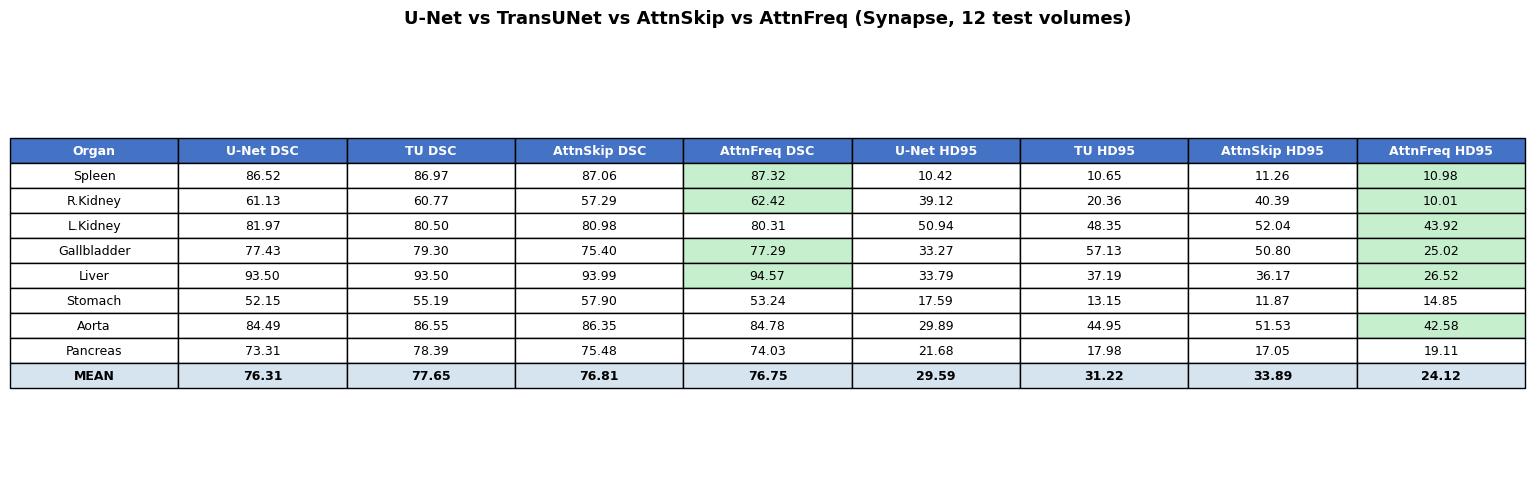

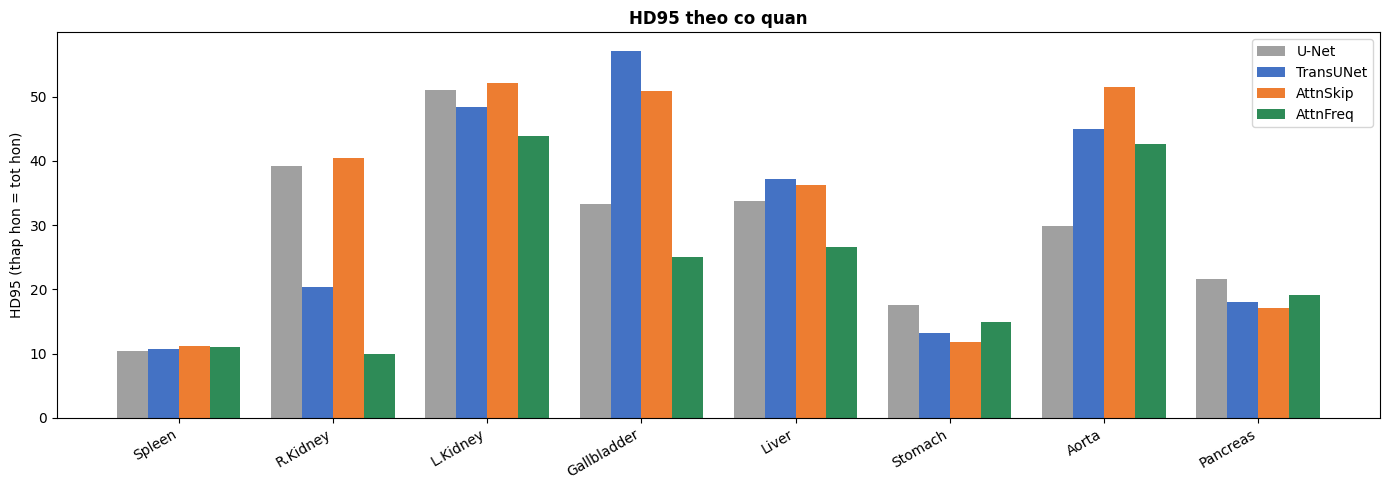

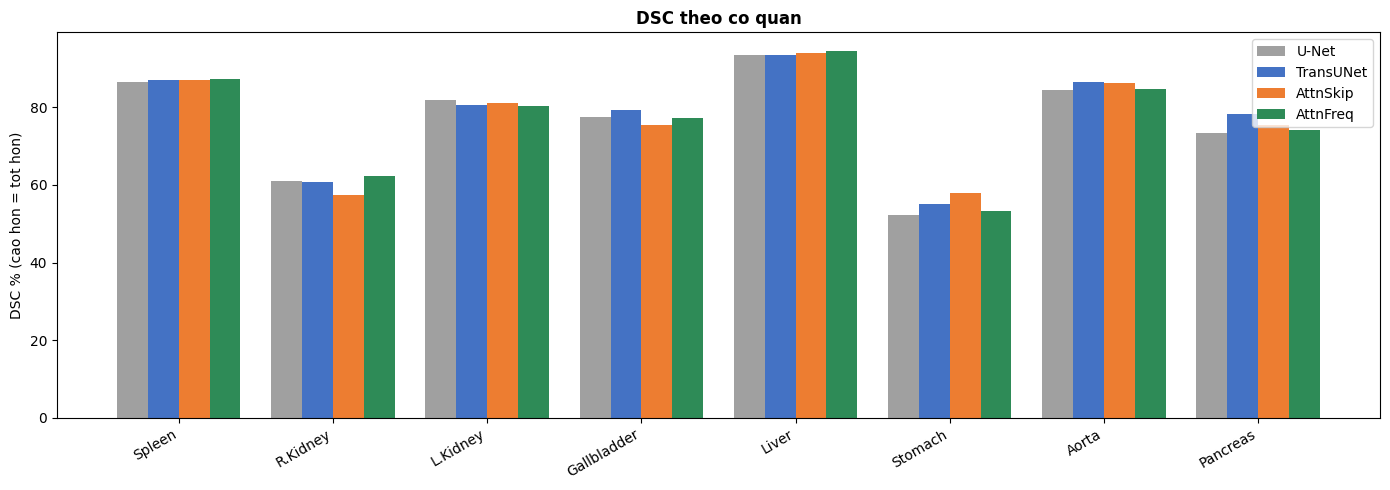

U-Net              : Mean DSC = 76.31%   Mean HD95 =  29.59
TransUNet (goc)    : Mean DSC = 77.65%   Mean HD95 =  31.22
TransUNet_AttnSkip : Mean DSC = 76.81%   Mean HD95 =  33.89
TransUNet_AttnFreq : Mean DSC = 76.75%   Mean HD95 =  24.12
AttnFreq vs AttnSkip :  DSC -0.06%   |   HD95 -9.76
AttnFreq vs TransUNet:  DSC -0.90%   |   HD95 -7.10
Freq BN-gamma norms (3 skip): [0.078, 0.277, 0.249]   (>0 = nhanh tan so da bat len)


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

ORGAN = ['Spleen', 'R.Kidney', 'L.Kidney', 'Gallbladder',
         'Liver', 'Stomach', 'Aorta', 'Pancreas']

# --- Baseline tu demo.ipynb ---
tu_dice  = np.array([0.8697, 0.6077, 0.8050, 0.7930, 0.9350, 0.5519, 0.8655, 0.7839])
tu_hd95  = np.array([10.65, 20.36, 48.35, 57.13, 37.19, 13.15, 44.95, 17.98])
un_dice  = np.array([0.8652, 0.6113, 0.8197, 0.7743, 0.9350, 0.5215, 0.8449, 0.7331])
un_hd95  = np.array([10.42, 39.12, 50.94, 33.27, 33.79, 17.59, 29.89, 21.68])

# --- TransUNet_AttnSkip: ket qua da chay o muc 4-5 phia tren ---
ag_dice  = np.array([0.8706, 0.5729, 0.8098, 0.7540, 0.9399, 0.5790, 0.8635, 0.7548])
ag_hd95  = np.array([11.26, 40.39, 52.04, 50.80, 36.17, 11.87, 51.53, 17.05])

# --- TransUNet_AttnFreq: ket qua vua train ---
m = np.load('/content/model/TU_AttnFreq_Synapse224/metrics.npy')   # (8,2): [dice, hd95]
af_dice = m[:, 0]
af_hd95 = m[:, 1]
try:
    gnorms = np.load('/content/model/TU_AttnFreq_Synapse224/gnorms.npy')
    gtxt = ', '.join(f'{g:.3f}' for g in gnorms)
except Exception:
    gtxt = 'N/A'

# ============ BANG SO SANH 4 MO HINH ============
fig, ax = plt.subplots(figsize=(17, 5.5)); ax.axis('off')
cols = ['Organ', 'U-Net DSC', 'TU DSC', 'AttnSkip DSC', 'AttnFreq DSC',
        'U-Net HD95', 'TU HD95', 'AttnSkip HD95', 'AttnFreq HD95']
rows = []
for i in range(8):
    rows.append([ORGAN[i],
                 f'{un_dice[i]*100:.2f}', f'{tu_dice[i]*100:.2f}', f'{ag_dice[i]*100:.2f}', f'{af_dice[i]*100:.2f}',
                 f'{un_hd95[i]:.2f}', f'{tu_hd95[i]:.2f}', f'{ag_hd95[i]:.2f}', f'{af_hd95[i]:.2f}'])
rows.append(['MEAN',
             f'{un_dice.mean()*100:.2f}', f'{tu_dice.mean()*100:.2f}', f'{ag_dice.mean()*100:.2f}', f'{af_dice.mean()*100:.2f}',
             f'{un_hd95.mean():.2f}', f'{tu_hd95.mean():.2f}', f'{ag_hd95.mean():.2f}', f'{af_hd95.mean():.2f}'])
tbl = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.15, 1.5)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#4472C4'); tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[9, j].set_facecolor('#D6E4F0'); tbl[9, j].set_text_props(fontweight='bold')
# To xanh khi AttnFreq tot hon AttnSkip
for i in range(8):
    if af_dice[i] > ag_dice[i]: tbl[i+1, 4].set_facecolor('#C6EFCE')
    if af_hd95[i] < ag_hd95[i]: tbl[i+1, 8].set_facecolor('#C6EFCE')
ax.set_title('U-Net vs TransUNet vs AttnSkip vs AttnFreq (Synapse, 12 test volumes)',
             fontsize=13, fontweight='bold', pad=20)
os.makedirs('/content/attnfreq_output', exist_ok=True)
plt.savefig('/content/attnfreq_output/compare_table.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ BIEU DO HD95 (muc tieu chinh cua Huong 2) ============
x = np.arange(8); wd = 0.2
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*wd, un_hd95, wd, label='U-Net', color='#A0A0A0')
ax.bar(x - 0.5*wd, tu_hd95, wd, label='TransUNet', color='#4472C4')
ax.bar(x + 0.5*wd, ag_hd95, wd, label='AttnSkip', color='#ED7D31')
ax.bar(x + 1.5*wd, af_hd95, wd, label='AttnFreq', color='#2E8B57')
ax.set_xticks(x); ax.set_xticklabels(ORGAN, rotation=30, ha='right')
ax.set_ylabel('HD95 (thap hon = tot hon)')
ax.set_title('HD95 theo co quan', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('/content/attnfreq_output/compare_hd95.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ BIEU DO DSC ============
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*wd, un_dice*100, wd, label='U-Net', color='#A0A0A0')
ax.bar(x - 0.5*wd, tu_dice*100, wd, label='TransUNet', color='#4472C4')
ax.bar(x + 0.5*wd, ag_dice*100, wd, label='AttnSkip', color='#ED7D31')
ax.bar(x + 1.5*wd, af_dice*100, wd, label='AttnFreq', color='#2E8B57')
ax.set_xticks(x); ax.set_xticklabels(ORGAN, rotation=30, ha='right')
ax.set_ylabel('DSC % (cao hon = tot hon)')
ax.set_title('DSC theo co quan', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('/content/attnfreq_output/compare_dsc.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ TONG KET ============
print('='*70)
print(f"U-Net              : Mean DSC = {un_dice.mean()*100:5.2f}%   Mean HD95 = {un_hd95.mean():6.2f}")
print(f"TransUNet (goc)    : Mean DSC = {tu_dice.mean()*100:5.2f}%   Mean HD95 = {tu_hd95.mean():6.2f}")
print(f"TransUNet_AttnSkip : Mean DSC = {ag_dice.mean()*100:5.2f}%   Mean HD95 = {ag_hd95.mean():6.2f}")
print(f"TransUNet_AttnFreq : Mean DSC = {af_dice.mean()*100:5.2f}%   Mean HD95 = {af_hd95.mean():6.2f}")
print('='*70)
print(f"AttnFreq vs AttnSkip :  DSC {(af_dice.mean()-ag_dice.mean())*100:+.2f}%   |   HD95 {af_hd95.mean()-ag_hd95.mean():+.2f}")
print(f"AttnFreq vs TransUNet:  DSC {(af_dice.mean()-tu_dice.mean())*100:+.2f}%   |   HD95 {af_hd95.mean()-tu_hd95.mean():+.2f}")
print(f"Freq BN-gamma norms (3 skip): [{gtxt}]   (>0 = nhanh tan so da bat len)")
print('='*70)

## 11. Trực quan hóa định tính (CT | Ground Truth | TransUNet_AttnFreq)

Overlay dự đoán của mô hình mới cho vài lát cắt nhiều cơ quan, để xem ranh giới có sắc hơn không.

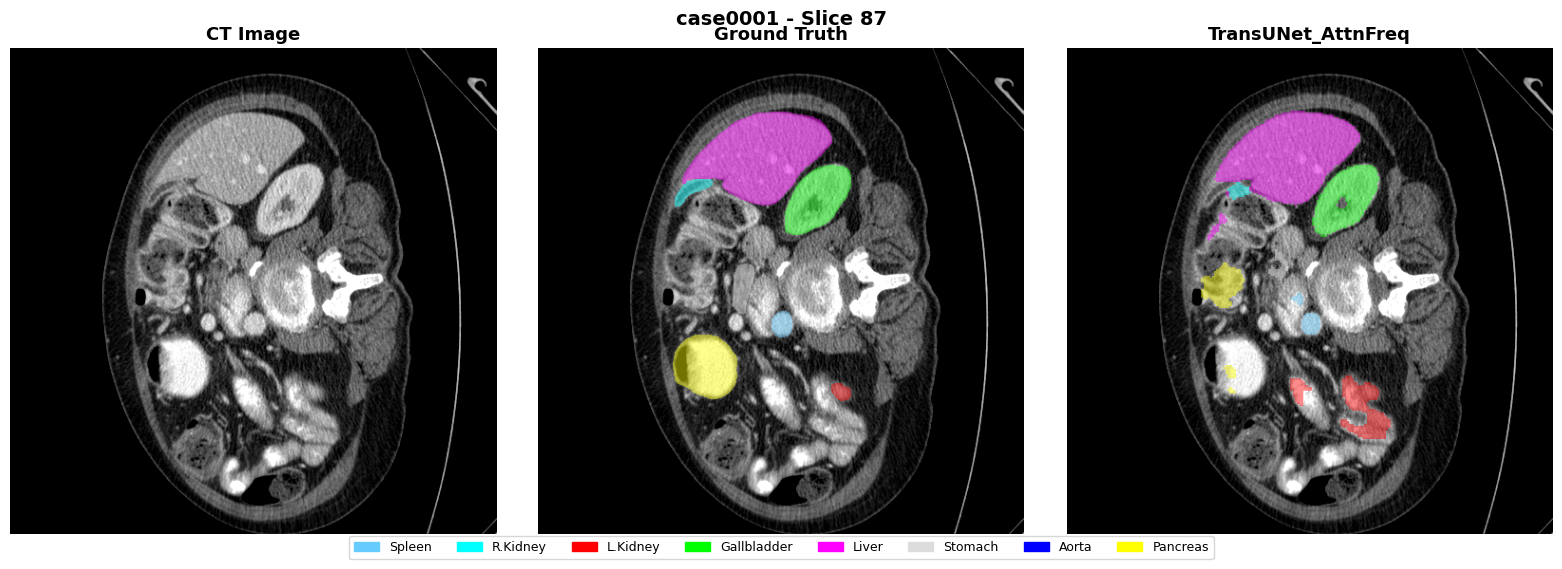

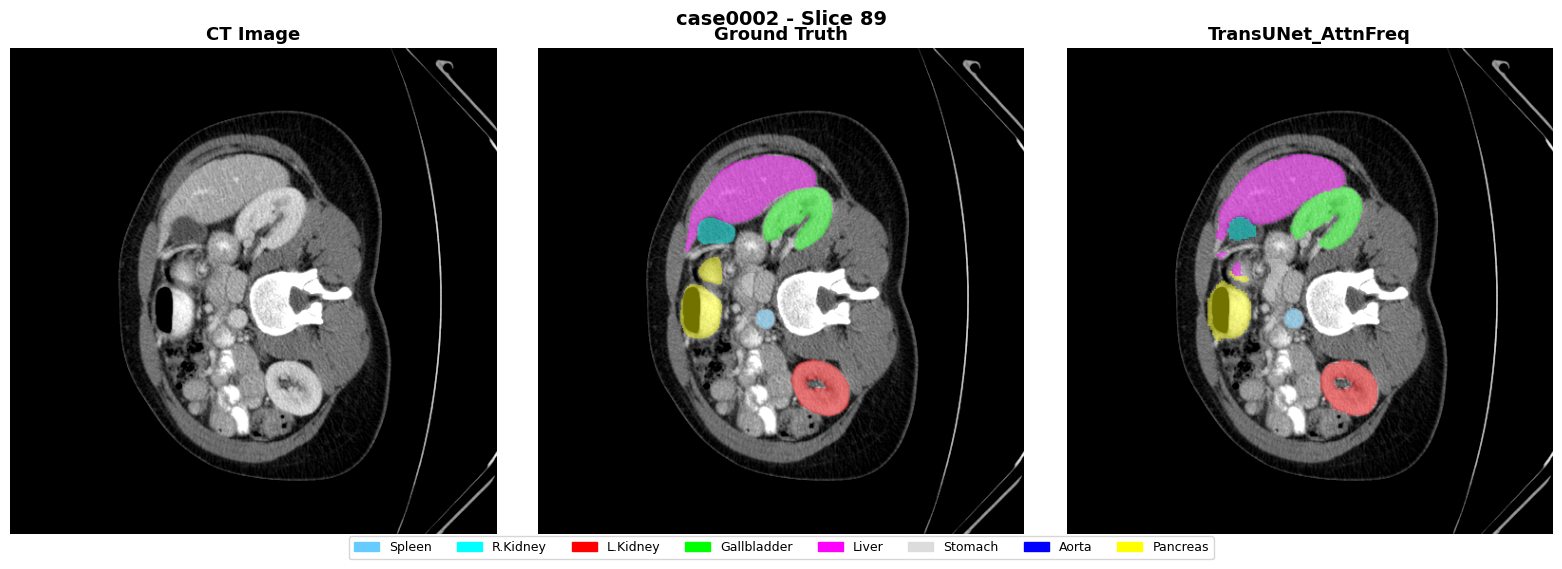

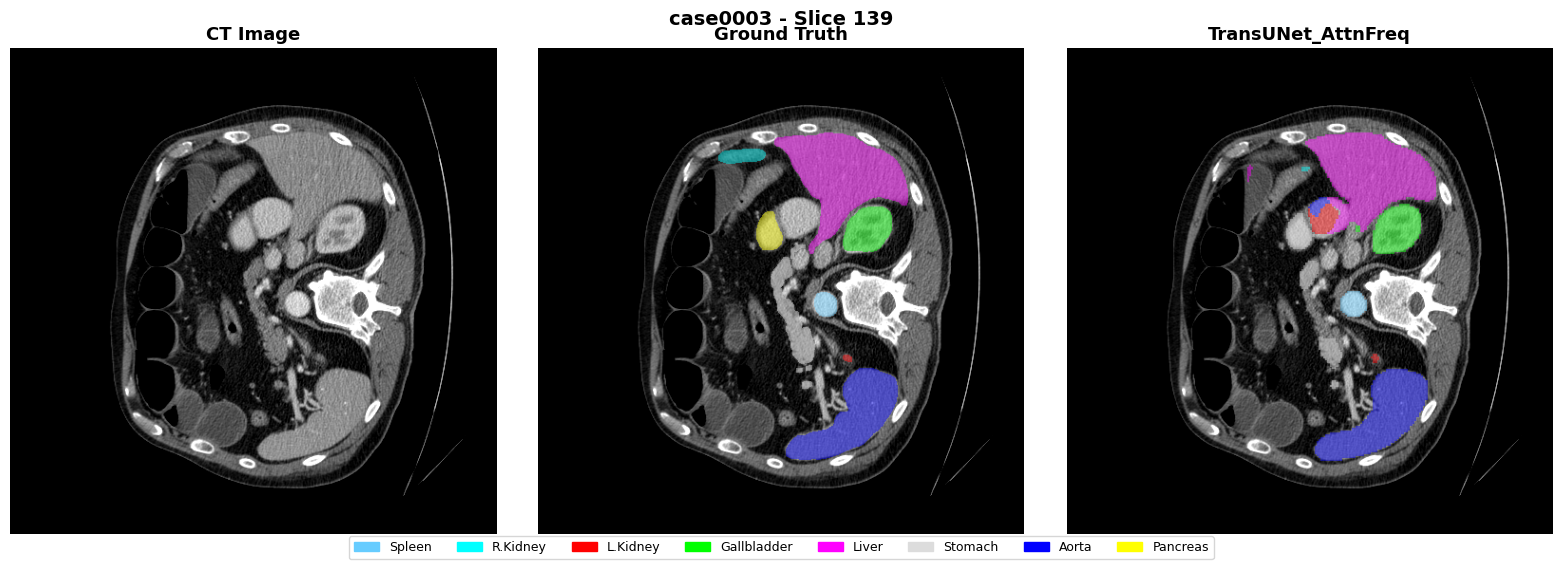

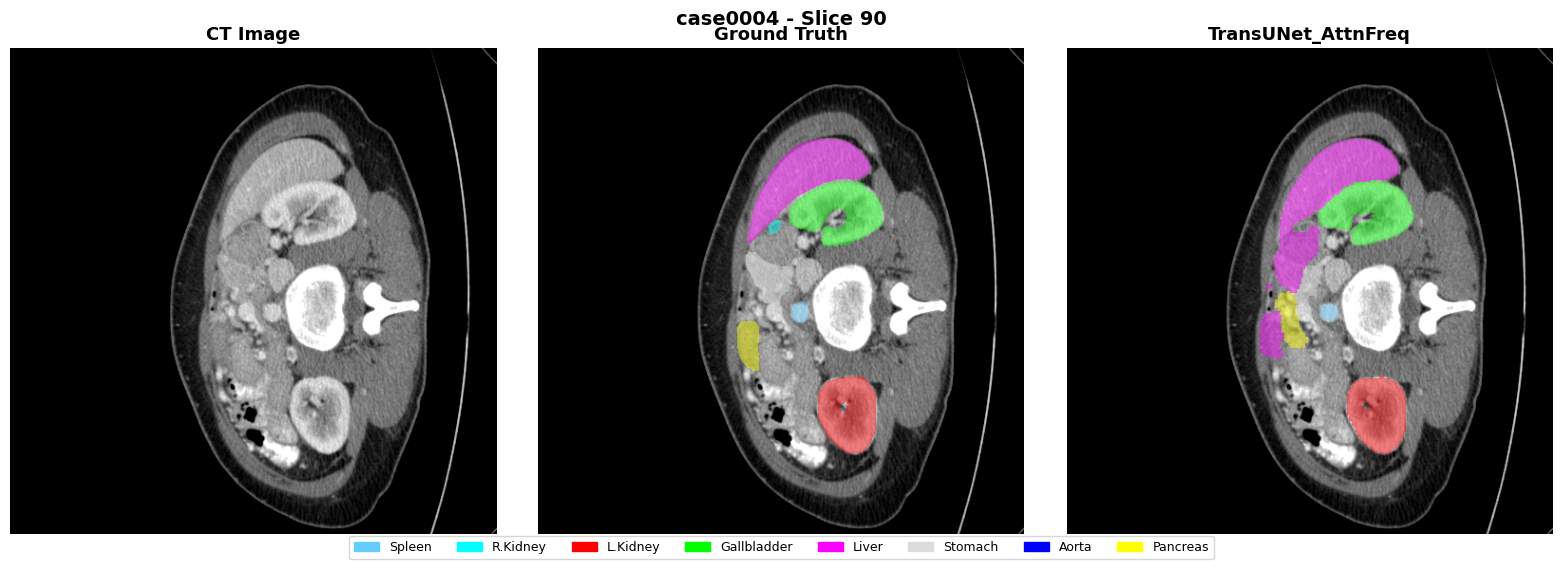

In [17]:
import os, sys, glob, h5py
import numpy as np, torch
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from scipy.ndimage import zoom

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnfreq import ViT_AttnFreq

ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}
CLR = np.array([[0,0,0],[102,204,255],[0,255,255],[255,0,0],[0,255,0],
                [255,0,255],[220,220,220],[0,0,255],[255,255,0]]) / 255.

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9; config_vit.n_skip = 3; config_vit.patches.grid = (14, 14)
net = ViT_AttnFreq(config_vit, img_size=224, num_classes=9).cuda()
_ckpt = sorted(glob.glob('/content/model/TU_AttnFreq_Synapse224/epoch_*.pth'),
               key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
net.load_state_dict(torch.load(_ckpt))
net.eval()

def predict(slc):
    h, w = slc.shape
    s = zoom(slc, (224/h, 224/w), order=3) if (h != 224 or w != 224) else slc
    with torch.no_grad():
        o = net(torch.from_numpy(s).unsqueeze(0).unsqueeze(0).float().cuda())
        o = torch.argmax(torch.softmax(o, 1), 1).squeeze(0).cpu().numpy()
    return zoom(o, (h/224, w/224), order=0).astype(int) if (h != 224 or w != 224) else o.astype(int)

def overlay(img, lbl, a=0.45):
    im = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([im]*3, -1).copy()
    for c in range(1, 9):
        msk = lbl == c
        if msk.any():
            for ch in range(3):
                rgb[:, :, ch][msk] = (1-a)*rgb[:, :, ch][msk] + a*CLR[c][ch]
    return np.clip(rgb, 0, 1)

out_dir = '/content/attnfreq_output'; os.makedirs(out_dir, exist_ok=True)
test_dir = '/content/data/Synapse/test_vol_h5'
cases = sorted([f.replace('.npy.h5', '') for f in os.listdir(test_dir)])[:4]

for case in cases:
    data = h5py.File(os.path.join(test_dir, f'{case}.npy.h5'), 'r')
    imgs, lbls = data['image'][:], data['label'][:]
    n = imgs.shape[0]
    si = sorted(range(n), key=lambda s: -len(np.unique(lbls[s])))[0]
    gt = lbls[si].astype(int)
    pred = predict(imgs[si])
    fig, ax = plt.subplots(1, 3, figsize=(16, 5.5))
    im_n = (imgs[si] - imgs[si].min()) / (imgs[si].max() - imgs[si].min() + 1e-8)
    ax[0].imshow(im_n, cmap='gray'); ax[0].set_title('CT Image', fontsize=13, fontweight='bold')
    ax[1].imshow(overlay(imgs[si], gt)); ax[1].set_title('Ground Truth', fontsize=13, fontweight='bold')
    ax[2].imshow(overlay(imgs[si], pred)); ax[2].set_title('TransUNet_AttnFreq', fontsize=13, fontweight='bold')
    for a_ in ax: a_.axis('off')
    patches = [mpatches.Patch(color=CLR[i], label=ORGAN[i]) for i in range(1, 9)]
    fig.legend(handles=patches, loc='lower center', ncol=8, fontsize=9, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f'{case} - Slice {si}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{out_dir}/{case}_s{si}.png', dpi=150, bbox_inches='tight'); plt.show()

In [18]:
# Dong goi ket qua AttnFreq de tai ve
!zip -r /content/attnfreq_output.zip /content/attnfreq_output/
from google.colab import files
files.download('/content/attnfreq_output.zip')

  adding: content/attnfreq_output/ (stored 0%)
  adding: content/attnfreq_output/compare_table.png (deflated 14%)
  adding: content/attnfreq_output/case0003_s139.png (deflated 3%)
  adding: content/attnfreq_output/compare_hd95.png (deflated 22%)
  adding: content/attnfreq_output/case0001_s87.png (deflated 3%)
  adding: content/attnfreq_output/compare_dsc.png (deflated 22%)
  adding: content/attnfreq_output/case0002_s89.png (deflated 4%)
  adding: content/attnfreq_output/case0004_s90.png (deflated 4%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Phần 12 — Lưu checkpoint & output (tải về máy)

Vì Colab xoá `/content/` khi hết session, cell dưới **đóng gói và tải về máy** các file
**dùng lại được** của 2 model đã train (AttnSkip, AttnFreq). Quy ước tên:

```
{model}_{mô tả}      ví dụ:
  attnskip_ep149_ckpt.pth      # checkpoint epoch cuối  (load lại / TTA / fine-tune)
  attnskip_metrics.npy         # DSC/HD95 per-organ     (vẽ bảng so sánh)
  attnskip_fig.zip             # bảng + biểu đồ + overlay
  attnfreq_ep149_ckpt.pth / attnfreq_metrics.npy / attnfreq_gnorms.npy / attnfreq_fig.zip
```

> Lần sau muốn chạy lại (vd TTA) mà không train: upload `*_ep149_ckpt.pth` lên Colab rồi copy
> vào đúng `/content/model/...` trước khi chạy cell test. Chỉ tải file tồn tại (có guard).

In [19]:
import os, glob, shutil
from google.colab import files

SAVE_DIR = '/content/saved_artifacts'
os.makedirs(SAVE_DIR, exist_ok=True)


def _latest_ckpt(folder):
    cks = glob.glob(os.path.join(folder, 'epoch_*.pth'))
    if not cks:
        return None
    return sorted(cks, key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]


def save_file(src, new_name):
    '''Copy src -> SAVE_DIR/new_name (chi khi src ton tai). Tra ve duong dan moi hoac None.'''
    if src and os.path.exists(src):
        dst = os.path.join(SAVE_DIR, new_name)
        shutil.copy(src, dst)
        print('  OK  ', new_name, f'({os.path.getsize(dst)/1e6:.1f} MB)')
        return dst
    print('  skip', new_name, '(khong tim thay:', src, ')')
    return None


def zip_dir(folder, zip_name):
    if os.path.isdir(folder) and os.listdir(folder):
        out = os.path.join(SAVE_DIR, zip_name)
        shutil.make_archive(out[:-4], 'zip', folder)
        print('  OK  ', zip_name, f'({os.path.getsize(out)/1e6:.1f} MB)')
        return out
    print('  skip', zip_name, '(folder rong/khong co)')
    return None


to_download = []

print('== AttnSkip ==')
ck = _latest_ckpt('/content/model/TU_AttnSkip_Synapse224')
ep = ck.split('epoch_')[-1].split('.pth')[0] if ck else '149'
to_download += [
    save_file(ck, f'attnskip_ep{ep}_ckpt.pth'),
    save_file('/content/model/TU_AttnSkip_Synapse224/metrics.npy', 'attnskip_metrics.npy'),
    zip_dir('/content/caitien_output', 'attnskip_fig.zip'),
]

print('== AttnFreq ==')
ck = _latest_ckpt('/content/model/TU_AttnFreq_Synapse224')
ep = ck.split('epoch_')[-1].split('.pth')[0] if ck else '149'
to_download += [
    save_file(ck, f'attnfreq_ep{ep}_ckpt.pth'),
    save_file('/content/model/TU_AttnFreq_Synapse224/metrics.npy', 'attnfreq_metrics.npy'),
    save_file('/content/model/TU_AttnFreq_Synapse224/gnorms.npy', 'attnfreq_gnorms.npy'),
    zip_dir('/content/attnfreq_output', 'attnfreq_fig.zip'),
]

# Tai tung file ve may
for f in to_download:
    if f:
        files.download(f)
print('\nDONE. Cac file da luu o', SAVE_DIR)

== AttnSkip ==
  OK   attnskip_ep149_ckpt.pth (422.7 MB)
  OK   attnskip_metrics.npy (0.0 MB)
  OK   attnskip_fig.zip (2.5 MB)
== AttnFreq ==
  OK   attnfreq_ep149_ckpt.pth (428.0 MB)
  OK   attnfreq_metrics.npy (0.0 MB)
  OK   attnfreq_gnorms.npy (0.0 MB)
  OK   attnfreq_fig.zip (2.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE. Cac file da luu o /content/saved_artifacts


# Phần 13 — TTA (Test-Time Augmentation) trên AttnSkip

**Không train lại** — chỉ dùng checkpoint AttnSkip đã có. Lúc test, mỗi lát cắt được dự đoán
trên **nhiều phiên bản lật** (gốc, lật ngang, lật dọc, lật cả hai), **lật ngược kết quả về**
rồi **trung bình xác suất softmax** → dự đoán ổn định hơn.

\[
P = \frac{1}{|T|}\sum_{t\in T} t^{-1}\big(\mathrm{softmax}(f(t(x)))\big)
\]

- `TTAWrapper` bọc quanh `ViT_AttnSkip`, trả về **xác suất trung bình** → dùng lại được hàm
  `test_single_volume` của repo (argmax không đổi khi softmax thêm lần nữa).
- **Lưu ý giải phẫu:** lật **ngang** đổi trái↔phải → có thể ảnh hưởng **R./L. Kidney**. Nếu 2
  thận tụt, đặt `TTA_FLIPS = ['v']` (chỉ lật dọc) hoặc bỏ bớt. Mặc định thử cả 4 view.
- Kết quả lưu `attnskip_tta_metrics.npy` (không ghi đè `metrics.npy` gốc).

In [20]:
%%writefile /content/TransUNet/test_attnskip_tta.py
import os, sys, glob, random, logging
import numpy as np, torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, '/content/TransUNet')
from datasets.dataset_synapse import Synapse_dataset
from utils import test_single_volume
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip

# ==== cau hinh TTA ====
TTA_FLIPS = ['h', 'v', 'hv']   # cac view ngoai goc; bo bot neu R/L Kidney tut (vd ['v'])
# ======================

random.seed(1234); np.random.seed(1234)
torch.manual_seed(1234); torch.cuda.manual_seed(1234)

log_dir = './test_log/test_log_AttnSkip_TTA'
os.makedirs(log_dir, exist_ok=True)
logging.basicConfig(filename=os.path.join(log_dir, 'attnskip_tta.txt'), level=logging.INFO,
                    format='[%(asctime)s.%(msecs)03d] %(message)s', datefmt='%H:%M:%S')
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))

ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}


class TTAWrapper(nn.Module):
    '''Boc model: tra ve XAC SUAT trung binh tren cac view lat.
    test_single_volume se argmax(softmax(.)) -> argmax khong doi.'''
    def __init__(self, net, flips):
        super().__init__()
        self.net = net
        self.flips = flips

    def _flip(self, x, mode):
        if mode == 'h':  return torch.flip(x, dims=[3])
        if mode == 'v':  return torch.flip(x, dims=[2])
        if mode == 'hv': return torch.flip(x, dims=[2, 3])
        return x

    def forward(self, x):
        prob = torch.softmax(self.net(x), dim=1)        # view goc
        n = 1
        for m in self.flips:
            o = torch.softmax(self.net(self._flip(x, m)), dim=1)
            o = self._flip(o, m)                        # lat nguoc ve
            prob = prob + o
            n += 1
        return prob / n

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9
config_vit.n_skip = 3
config_vit.patches.grid = (14, 14)
base = ViT_AttnSkip(config_vit, img_size=224, num_classes=9).cuda()

ckpt = sorted(glob.glob('/content/model/TU_AttnSkip_Synapse224/epoch_*.pth'),
              key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
print('Load checkpoint:', ckpt)
base.load_state_dict(torch.load(ckpt))
base.eval()
net = TTAWrapper(base, TTA_FLIPS).cuda().eval()
print('TTA views:', ['orig'] + TTA_FLIPS)

db = Synapse_dataset(base_dir='/content/data/Synapse/test_vol_h5',
                     split='test_vol', list_dir='./lists/lists_Synapse')
loader = DataLoader(db, batch_size=1, shuffle=False, num_workers=1)

metric_list = 0.0
for i, batch in tqdm(enumerate(loader)):
    img, lbl, name = batch['image'], batch['label'], batch['case_name'][0]
    mi = test_single_volume(img, lbl, net, classes=9, patch_size=[224, 224],
                            test_save_path=None, case=name, z_spacing=1)
    metric_list += np.array(mi)
    logging.info(f'idx {i} {name} dice={np.mean(mi, axis=0)[0]:.4f} hd95={np.mean(mi, axis=0)[1]:.2f}')

metric_list = metric_list / len(db)
for i in range(1, 9):
    logging.info(f'{ORGAN[i]}: dice={metric_list[i-1][0]:.4f} hd95={metric_list[i-1][1]:.2f}')
logging.info(f'MEAN: dice={np.mean(metric_list, axis=0)[0]:.4f} hd95={np.mean(metric_list, axis=0)[1]:.2f}')

np.save('/content/model/TU_AttnSkip_Synapse224/metrics_tta.npy', metric_list)
print('Saved metrics_tta.npy')

Writing /content/TransUNet/test_attnskip_tta.py


In [21]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python test_attnskip_tta.py

/content/TransUNet
Load checkpoint: /content/model/TU_AttnSkip_Synapse224/epoch_149.pth
TTA views: ['orig', 'h', 'v', 'hv']
0it [00:00, ?it/s]idx 0 case0008 dice=0.6259 hd95=17.36
1it [02:34, 154.36s/it]idx 1 case0022 dice=0.8769 hd95=22.46
2it [04:04, 116.31s/it]idx 2 case0038 dice=0.7473 hd95=61.21
3it [05:37, 106.00s/it]idx 3 case0036 dice=0.8387 hd95=9.25
4it [08:58, 143.33s/it]idx 4 case0032 dice=0.7909 hd95=14.48
5it [11:30, 146.50s/it]idx 5 case0002 dice=0.8610 hd95=21.40
6it [13:53, 145.29s/it]idx 6 case0029 dice=0.6460 hd95=41.47
7it [15:34, 130.72s/it]idx 7 case0003 dice=0.5097 hd95=72.21
8it [19:09, 157.67s/it]idx 8 case0001 dice=0.7355 hd95=45.71
9it [21:47, 157.76s/it]idx 9 case0004 dice=0.7903 hd95=30.67
10it [24:11, 153.55s/it]idx 10 case0025 dice=0.7177 hd95=57.94
11it [25:38, 133.19s/it]idx 11 case0035 dice=0.8877 hd95=3.34
12it [27:03, 135.27s/it]
Spleen: dice=0.8678 hd95=7.65
R.Kidney: dice=0.6127 hd95=14.33
L.Kidney: dice=0.7394 hd95=52.25
Gallbladder: dice=0.7286 h

In [22]:
# Tai metrics TTA ve may
import os, shutil
from google.colab import files
os.makedirs('/content/saved_artifacts', exist_ok=True)
src = '/content/model/TU_AttnSkip_Synapse224/metrics_tta.npy'
if os.path.exists(src):
    dst = '/content/saved_artifacts/attnskip_tta_metrics.npy'
    shutil.copy(src, dst)
    print('OK  attnskip_tta_metrics.npy')
    files.download(dst)
else:
    print('Chua co metrics_tta.npy - chay cell test TTA truoc')

OK  attnskip_tta_metrics.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Phần 14 — Weighted CE trên AttnSkip (`AttnSkip_wCE`)

Giữ **nguyên kiến trúc AttnSkip** và pipeline (SGD, poly-LR, 150 epoch), **chỉ đổi loss**:

\[
\mathcal{L} = 0.5\cdot \mathrm{CE}_{\mathbf{w}} + 0.5\cdot \mathrm{Dice}
\]

Trọng số lớp \(\mathbf{w}\) tính từ phân bố pixel trong `data.ipynb` theo **sqrt nghịch tần suất**,
chuẩn hoá mean = 1, clamp [0.5, 4.0] (nhẹ, tránh nổ loss / cơ quan lớn tụt mạnh):

| Lớp | bg | Spleen | R.Kid | L.Kid | Gallb | Liver | Stom | Aorta | Panc |
|-----|----|--------|-------|-------|-------|-------|------|-------|------|
| w   | 0.47 | 1.18 | **2.29** | 0.98 | 0.98 | 0.47 | **1.40** | 0.64 | 0.61 |

→ Cơ quan **hiếm** (R.Kidney, Stomach) được ưu tiên; nền & gan bị giảm. **Dice giữ nguyên**
(không weight) vì Dice vốn ít nhạy imbalance. Checkpoint: `/content/model/TU_AttnSkip_wCE_Synapse224/`.

> **Kỳ vọng:** DSC cơ quan nhỏ tăng; mean **có thể đi ngang** — thành công = Stomach/R.Kidney/Pancreas
> cải thiện, không bắt buộc vượt 77.6%.

In [23]:
%%writefile /content/TransUNet/train_attnskip_wce.py
import os, sys, random, logging
import numpy as np, torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
from torch.nn.modules.loss import CrossEntropyLoss
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip
from datasets.dataset_synapse import Synapse_dataset, RandomGenerator
from utils import DiceLoss

# ===================== config =====================
ROOT = '/content/data/Synapse/train_npz'
LIST = './lists/lists_Synapse'
NUM_CLASSES = 9
MAX_EPOCHS  = 150          # <-- giam (vd 60) neu muon chay nhanh
BATCH       = 24
BASE_LR     = 0.01
IMG         = 224
SEED        = 1234
# ==================================================

# Pixel counts tu data.ipynb (class 0..8)
COUNTS = np.array([554315625, 922056, 245028, 1344662, 1333973,
                   14192919, 651861, 3119429, 3474831], dtype=np.float64)
freq = COUNTS / COUNTS.sum()
w = 1.0 / np.sqrt(freq)          # sqrt nghich tan suat
w = w / w.mean()                 # chuan hoa mean=1
w = np.clip(w, 0.5, 4.0)         # clamp nhe
w = w / w.mean()
CLASS_W = torch.tensor(w, dtype=torch.float32)
print('Class weights:', [round(float(x), 3) for x in CLASS_W])

cudnn.benchmark = False; cudnn.deterministic = True
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)

snapshot_path = '/content/model/TU_AttnSkip_wCE_Synapse224'
os.makedirs(snapshot_path, exist_ok=True)
logging.basicConfig(filename=snapshot_path + '/log.txt', level=logging.INFO,
                    format='[%(asctime)s.%(msecs)03d] %(message)s', datefmt='%H:%M:%S')
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = NUM_CLASSES
config_vit.n_skip = 3
config_vit.patches.grid = (IMG // 16, IMG // 16)
net = ViT_AttnSkip(config_vit, img_size=IMG, num_classes=NUM_CLASSES).cuda()
net.load_from(weights=np.load(config_vit.pretrained_path))
print('AttnSkip_wCE params: %.2f M' % (sum(p.numel() for p in net.parameters()) / 1e6))

db = Synapse_dataset(base_dir=ROOT, list_dir=LIST, split='train',
                     transform=transforms.Compose([RandomGenerator(output_size=[IMG, IMG])]))
print('Train set size:', len(db))

def worker_init_fn(wid):
    random.seed(SEED + wid)

loader = DataLoader(db, batch_size=BATCH, shuffle=True, num_workers=8,
                    pin_memory=True, worker_init_fn=worker_init_fn)

ce_loss = CrossEntropyLoss(weight=CLASS_W.cuda())   # <-- WEIGHTED CE
dice_loss = DiceLoss(NUM_CLASSES)                   # Dice giu nguyen
optimizer = optim.SGD(net.parameters(), lr=BASE_LR, momentum=0.9, weight_decay=0.0001)
net.train()

max_iter = MAX_EPOCHS * len(loader)
it = 0
for ep in tqdm(range(MAX_EPOCHS), ncols=70):
    for batch in loader:
        img = batch['image'].cuda()
        lab = batch['label'].cuda()
        out = net(img)
        loss_ce = ce_loss(out, lab[:].long())
        loss_dice = dice_loss(out, lab, softmax=True)
        loss = 0.5 * loss_ce + 0.5 * loss_dice
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        lr_ = BASE_LR * (1.0 - it / max_iter) ** 0.9
        for g in optimizer.param_groups:
            g['lr'] = lr_
        it += 1
        if it % 50 == 0:
            logging.info('iter %d : loss %.4f | ce %.4f dice %.4f' % (
                it, loss.item(), loss_ce.item(), loss_dice.item()))
    if ep > int(MAX_EPOCHS / 2) and (ep + 1) % 50 == 0:
        torch.save(net.state_dict(), os.path.join(snapshot_path, 'epoch_%d.pth' % ep))
        logging.info('save epoch_%d.pth' % ep)
    if ep >= MAX_EPOCHS - 1:
        torch.save(net.state_dict(), os.path.join(snapshot_path, 'epoch_%d.pth' % ep))
        logging.info('save epoch_%d.pth' % ep)

print('Training Finished (AttnSkip_wCE)!')

Writing /content/TransUNet/train_attnskip_wce.py


In [24]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python train_attnskip_wce.py

/content/TransUNet
Class weights: [0.467, 1.178, 2.285, 0.975, 0.979, 0.467, 1.401, 0.64, 0.607]
AttnSkip_wCE params: 105.61 M
Train set size: 2211
  1%|▏                              | 1/150 [00:28<1:09:50, 28.13s/it]iter 100 : loss 0.4488 | ce 0.1895 dice 0.7082
iter 150 : loss 0.4324 | ce 0.1648 dice 0.7001
  1%|▍                              | 2/150 [00:55<1:08:03, 27.59s/it]iter 200 : loss 0.4288 | ce 0.1637 dice 0.6940
iter 250 : loss 0.4327 | ce 0.1762 dice 0.6893
  2%|▌                              | 3/150 [01:22<1:07:04, 27.38s/it]iter 300 : loss 0.3901 | ce 0.1086 dice 0.6716
iter 350 : loss 0.3788 | ce 0.0913 dice 0.6663
  3%|▊                              | 4/150 [01:49<1:06:23, 27.28s/it]iter 400 : loss 0.3698 | ce 0.1119 dice 0.6277
iter 450 : loss 0.3583 | ce 0.1541 dice 0.5625
  3%|█                              | 5/150 [02:16<1:05:53, 27.26s/it]iter 500 : loss 0.3113 | ce 0.0800 dice 0.5427
iter 550 : loss 0.3206 | ce 0.1318 dice 0.5095
  4%|█▏                         

In [25]:
# Tai checkpoint wCE ve may (chay ngay sau khi train xong, truoc khi mat session)
import os, glob, shutil
from google.colab import files
os.makedirs('/content/saved_artifacts', exist_ok=True)
cks = glob.glob('/content/model/TU_AttnSkip_wCE_Synapse224/epoch_*.pth')
if cks:
    ck = sorted(cks, key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
    ep = ck.split('epoch_')[-1].split('.pth')[0]
    dst = f'/content/saved_artifacts/attnskip_wce_ep{ep}_ckpt.pth'
    shutil.copy(ck, dst)
    print('OK ', os.path.basename(dst), f'({os.path.getsize(dst)/1e6:.1f} MB)')
    files.download(dst)
else:
    print('Chua co checkpoint wCE - train truoc')

OK  attnskip_wce_ep149_ckpt.pth (422.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Đánh giá `AttnSkip_wCE` — cả thường lẫn + TTA

Một script chạy 2 lần: (1) dự đoán thường → `metrics_wce.npy`, (2) dự đoán + TTA →
`metrics_wce_tta.npy`. Nhờ vậy bảng tổng có đủ 4 biến thể mới so với AttnSkip gốc.

In [26]:
%%writefile /content/TransUNet/test_attnskip_wce.py
import os, sys, glob, random, logging
import numpy as np, torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, '/content/TransUNet')
from datasets.dataset_synapse import Synapse_dataset
from utils import test_single_volume
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_attnskip import ViT_AttnSkip

TTA_FLIPS = ['h', 'v', 'hv']

random.seed(1234); np.random.seed(1234)
torch.manual_seed(1234); torch.cuda.manual_seed(1234)

log_dir = './test_log/test_log_AttnSkip_wCE'
os.makedirs(log_dir, exist_ok=True)
logging.basicConfig(filename=os.path.join(log_dir, 'attnskip_wce.txt'), level=logging.INFO,
                    format='[%(asctime)s.%(msecs)03d] %(message)s', datefmt='%H:%M:%S')
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))

ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}


class TTAWrapper(nn.Module):
    def __init__(self, net, flips):
        super().__init__(); self.net = net; self.flips = flips
    def _flip(self, x, m):
        if m == 'h':  return torch.flip(x, dims=[3])
        if m == 'v':  return torch.flip(x, dims=[2])
        if m == 'hv': return torch.flip(x, dims=[2, 3])
        return x
    def forward(self, x):
        prob = torch.softmax(self.net(x), dim=1); n = 1
        for m in self.flips:
            o = torch.softmax(self.net(self._flip(x, m)), dim=1)
            prob = prob + self._flip(o, m); n += 1
        return prob / n


config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9; config_vit.n_skip = 3; config_vit.patches.grid = (14, 14)
base = ViT_AttnSkip(config_vit, img_size=224, num_classes=9).cuda()
ckpt = sorted(glob.glob('/content/model/TU_AttnSkip_wCE_Synapse224/epoch_*.pth'),
              key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
print('Load checkpoint:', ckpt)
base.load_state_dict(torch.load(ckpt))
base.eval()

db = Synapse_dataset(base_dir='/content/data/Synapse/test_vol_h5',
                     split='test_vol', list_dir='./lists/lists_Synapse')


def run(model, tag, out_name):
    loader = DataLoader(db, batch_size=1, shuffle=False, num_workers=1)
    ml = 0.0
    for i, batch in tqdm(enumerate(loader), desc=tag):
        img, lbl, name = batch['image'], batch['label'], batch['case_name'][0]
        mi = test_single_volume(img, lbl, model, classes=9, patch_size=[224, 224],
                                test_save_path=None, case=name, z_spacing=1)
        ml += np.array(mi)
    ml = ml / len(db)
    for i in range(1, 9):
        logging.info(f'[{tag}] {ORGAN[i]}: dice={ml[i-1][0]:.4f} hd95={ml[i-1][1]:.2f}')
    logging.info(f'[{tag}] MEAN: dice={np.mean(ml, axis=0)[0]:.4f} hd95={np.mean(ml, axis=0)[1]:.2f}')
    np.save(f'/content/model/TU_AttnSkip_wCE_Synapse224/{out_name}', ml)
    print(f'Saved {out_name}')


# (1) wCE thuong
run(base, 'wCE', 'metrics_wce.npy')
# (2) wCE + TTA
run(TTAWrapper(base, TTA_FLIPS).cuda().eval(), 'wCE+TTA', 'metrics_wce_tta.npy')

Writing /content/TransUNet/test_attnskip_wce.py


In [27]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python test_attnskip_wce.py

/content/TransUNet
Load checkpoint: /content/model/TU_AttnSkip_wCE_Synapse224/epoch_149.pth
wCE: 12it [25:04, 125.39s/it]
[wCE] Spleen: dice=0.8616 hd95=11.25
[wCE] R.Kidney: dice=0.6169 hd95=34.08
[wCE] L.Kidney: dice=0.8277 hd95=49.94
[wCE] Gallbladder: dice=0.7833 hd95=38.42
[wCE] Liver: dice=0.9401 hd95=26.53
[wCE] Stomach: dice=0.5499 hd95=16.10
[wCE] Aorta: dice=0.8466 hd95=40.04
[wCE] Pancreas: dice=0.7349 hd95=17.02
[wCE] MEAN: dice=0.7701 hd95=29.17
Saved metrics_wce.npy
wCE+TTA: 12it [26:55, 134.64s/it]
[wCE+TTA] Spleen: dice=0.8586 hd95=10.00
[wCE+TTA] R.Kidney: dice=0.5851 hd95=39.57
[wCE+TTA] L.Kidney: dice=0.7843 hd95=49.35
[wCE+TTA] Gallbladder: dice=0.7335 hd95=70.54
[wCE+TTA] Liver: dice=0.9380 hd95=32.62
[wCE+TTA] Stomach: dice=0.5413 hd95=15.43
[wCE+TTA] Aorta: dice=0.8327 hd95=67.14
[wCE+TTA] Pancreas: dice=0.7243 hd95=16.93
[wCE+TTA] MEAN: dice=0.7497 hd95=37.70
Saved metrics_wce_tta.npy


In [28]:
# Tai metrics wCE + wCE_TTA ve may
import os, shutil
from google.colab import files
os.makedirs('/content/saved_artifacts', exist_ok=True)
pairs = [('/content/model/TU_AttnSkip_wCE_Synapse224/metrics_wce.npy',     'attnskip_wce_metrics.npy'),
         ('/content/model/TU_AttnSkip_wCE_Synapse224/metrics_wce_tta.npy', 'attnskip_wce_tta_metrics.npy')]
for src, name in pairs:
    if os.path.exists(src):
        dst = '/content/saved_artifacts/' + name
        shutil.copy(src, dst)
        print('OK ', name)
        files.download(dst)
    else:
        print('skip', name, '(chua co)')

OK  attnskip_wce_metrics.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

OK  attnskip_wce_tta_metrics.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Phần 15 — So sánh tổng hợp pipeline (TTA → Weighted CE)

Gộp mọi biến thể đã có. Tự đọc các `metrics*.npy` tồn tại; baseline TU & U-Net lấy từ
`demo.ipynb`. **Tập trung cơ quan nhỏ** (R.Kidney, Gallbladder, Stomach, Pancreas) — nơi
Weighted CE kỳ vọng giúp nhất.

Model              |  Mean DSC | Mean HD95 | Small-organ DSC
------------------------------------------------------------------------------
U-Net              |    76.31% |     29.59 |          66.00%
TransUNet          |    77.65% |     31.22 |          68.41%
AttnSkip           |    77.61% |     28.03 |          68.66%
AttnSkip+TTA       |    75.23% |     33.12 |          65.74%
AttnSkip_wCE       |    77.01% |     29.17 |          67.12%
AttnSkip_wCE+TTA   |    74.97% |     37.70 |          64.61%


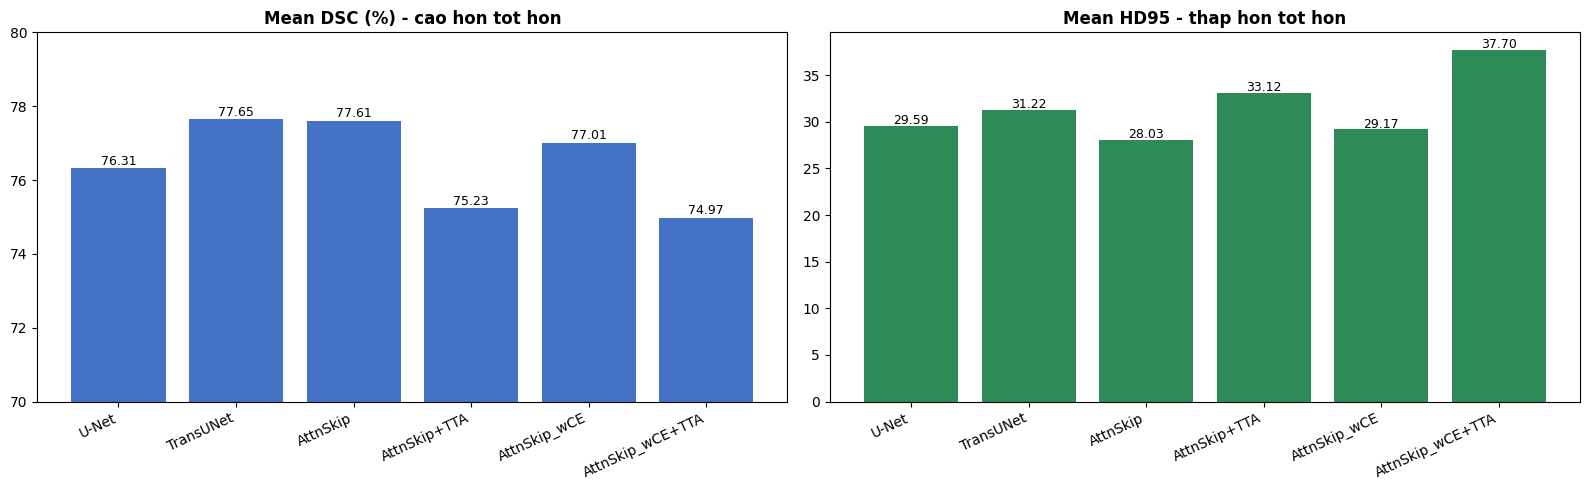

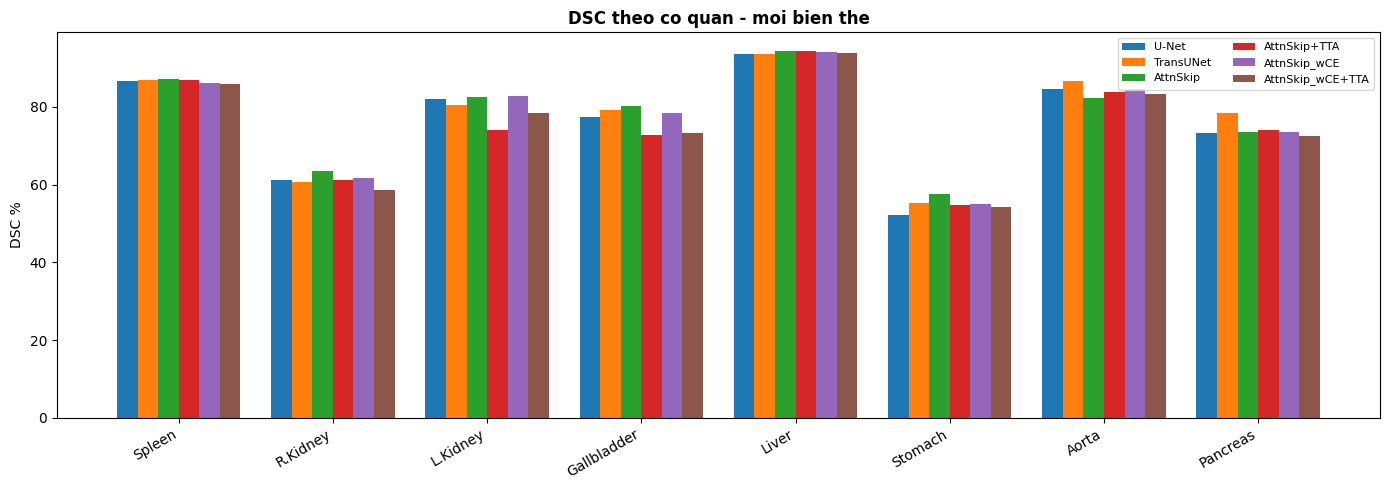

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

ORGAN = ['Spleen', 'R.Kidney', 'L.Kidney', 'Gallbladder', 'Liver', 'Stomach', 'Aorta', 'Pancreas']
SMALL = [1, 3, 5, 7]  # R.Kidney, Gallbladder, Stomach, Pancreas (index 0-based)

# Baseline hardcoded tu demo.ipynb
tu_dice = np.array([0.8697, 0.6077, 0.8050, 0.7930, 0.9350, 0.5519, 0.8655, 0.7839])
tu_hd95 = np.array([10.65, 20.36, 48.35, 57.13, 37.19, 13.15, 44.95, 17.98])
un_dice = np.array([0.8652, 0.6113, 0.8197, 0.7743, 0.9350, 0.5215, 0.8449, 0.7331])
un_hd95 = np.array([10.42, 39.12, 50.94, 33.27, 33.79, 17.59, 29.89, 21.68])

# AttnSkip goc (run moi nhat, cell 11) - fallback neu khong co file
ag_dice = np.array([0.8717, 0.6360, 0.8242, 0.8012, 0.9443, 0.5753, 0.8220, 0.7340])
ag_hd95 = np.array([11.08, 36.04, 37.02, 35.49, 26.78, 14.88, 43.91, 19.01])


def load(path):
    if os.path.exists(path):
        m = np.load(path)
        return m[:, 0], m[:, 1]
    return None


P = '/content/model'
variants = [('U-Net',            un_dice, un_hd95),
            ('TransUNet',        tu_dice, tu_hd95),
            ('AttnSkip',         ag_dice, ag_hd95)]

for name, path in [('AttnSkip+TTA',     f'{P}/TU_AttnSkip_Synapse224/metrics_tta.npy'),
                   ('AttnSkip_wCE',     f'{P}/TU_AttnSkip_wCE_Synapse224/metrics_wce.npy'),
                   ('AttnSkip_wCE+TTA', f'{P}/TU_AttnSkip_wCE_Synapse224/metrics_wce_tta.npy')]:
    r = load(path)
    if r is not None:
        variants.append((name, r[0], r[1]))
    else:
        print(f'(chua co) {name}: {path}')

# ===== Bang tong =====
print('=' * 78)
print(f'{"Model":18s} | {"Mean DSC":>9s} | {"Mean HD95":>9s} | {"Small-organ DSC":>15s}')
print('-' * 78)
for name, d, h in variants:
    print(f'{name:18s} | {d.mean()*100:8.2f}% | {h.mean():9.2f} | {d[SMALL].mean()*100:14.2f}%')
print('=' * 78)

# ===== Bieu do Mean DSC & HD95 =====
names = [v[0] for v in variants]
dsc_means = [v[1].mean()*100 for v in variants]
hd_means = [v[2].mean() for v in variants]
x = np.arange(len(names))
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
b1 = ax[0].bar(x, dsc_means, color='#4472C4'); ax[0].set_title('Mean DSC (%) - cao hon tot hon', fontweight='bold')
ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=25, ha='right'); ax[0].set_ylim(70, 80)
for b, v in zip(b1, dsc_means): ax[0].text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.2f}', ha='center', fontsize=9)
b2 = ax[1].bar(x, hd_means, color='#2E8B57'); ax[1].set_title('Mean HD95 - thap hon tot hon', fontweight='bold')
ax[1].set_xticks(x); ax[1].set_xticklabels(names, rotation=25, ha='right')
for b, v in zip(b2, hd_means): ax[1].text(b.get_x()+b.get_width()/2, v+0.2, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
os.makedirs('/content/pipeline_output', exist_ok=True)
plt.savefig('/content/pipeline_output/compare_pipeline.png', dpi=150, bbox_inches='tight'); plt.show()

# ===== Per-organ DSC cua cac bien the AttnSkip (neu co wCE) =====
fig, ax = plt.subplots(figsize=(14, 5))
xo = np.arange(8); wd = 0.8 / len(variants)
for k, (name, d, h) in enumerate(variants):
    ax.bar(xo + k*wd, d*100, wd, label=name)
ax.set_xticks(xo + wd*(len(variants)-1)/2); ax.set_xticklabels(ORGAN, rotation=30, ha='right')
ax.set_ylabel('DSC %'); ax.set_title('DSC theo co quan - moi bien the', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('/content/pipeline_output/compare_pipeline_perorgan.png', dpi=150, bbox_inches='tight'); plt.show()

In [30]:
# Dong goi TAT CA artifacts da luu + bieu do pipeline -> 1 file zip tai ve
import os, shutil
from google.colab import files
SAVE_DIR = '/content/saved_artifacts'
os.makedirs(SAVE_DIR, exist_ok=True)
# them bieu do pipeline vao goi
if os.path.isdir('/content/pipeline_output'):
    for f in os.listdir('/content/pipeline_output'):
        shutil.copy(os.path.join('/content/pipeline_output', f), os.path.join(SAVE_DIR, f))

print('Noi dung saved_artifacts:')
for f in sorted(os.listdir(SAVE_DIR)):
    print('  ', f, f'({os.path.getsize(os.path.join(SAVE_DIR, f))/1e6:.1f} MB)')

shutil.make_archive('/content/all_artifacts', 'zip', SAVE_DIR)
print('\nTai all_artifacts.zip ...')
files.download('/content/all_artifacts.zip')

Noi dung saved_artifacts:
   attnfreq_ep149_ckpt.pth (428.0 MB)
   attnfreq_fig.zip (2.6 MB)
   attnfreq_gnorms.npy (0.0 MB)
   attnfreq_metrics.npy (0.0 MB)
   attnskip_ep149_ckpt.pth (422.7 MB)
   attnskip_fig.zip (2.5 MB)
   attnskip_metrics.npy (0.0 MB)
   attnskip_tta_metrics.npy (0.0 MB)
   attnskip_wce_ep149_ckpt.pth (422.7 MB)
   attnskip_wce_metrics.npy (0.0 MB)
   attnskip_wce_tta_metrics.npy (0.0 MB)
   compare_pipeline.png (0.1 MB)
   compare_pipeline_perorgan.png (0.1 MB)

Tai all_artifacts.zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>